In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import torch
torch.set_num_threads(4)

device = 'cuda:0'


batch_size = 4
num_epochs = 200
checkpoint_frequency = 2
plot_frequency = 5
validation_frequency = 5
learning_rate = 5e-4
l2_lambda = 5e-6

ckpt_dir   = "checkpoints/run_9_cN4_5_fast_time_pooling"
os.makedirs(ckpt_dir, exist_ok=True)



In [2]:
import os, builtins
from datetime import datetime
import matplotlib.pyplot as plt

# 1) set up your log directory
LOG_DIR = ckpt_dir

# 2) intercept print() so it also writes to notebook.log
_log_f = open(os.path.join(LOG_DIR, "notebook.log"), "a")
_orig_print = builtins.print
def print_and_log(*args, **kwargs):
    _orig_print(*args, **kwargs)
    line = " ".join(str(a) for a in args)
    _log_f.write(line + "\n")
    _log_f.flush()
builtins.print = print_and_log

# 3) intercept plt.show() so it also saves each figure with a timestamp
_orig_show = plt.show
def show_and_log(*args, filename=None, **kwargs):
    # get current figure
    fig = plt.gcf()
    # generate timestamp
    ts = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    # choose filename
    fname = filename or f"fig_{ts}.png"
    # save to logs/
    fig.savefig(os.path.join(LOG_DIR, fname))
    # display inline as before
    return _orig_show(*args, **kwargs)

plt.show = show_and_log


In [3]:
# Standard library
import glob
import math
import os
import random

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torchvision.models as models
from torchvision import transforms
from torchvision.io import read_image

from PIL import Image
from einops import rearrange, repeat
from torch.utils.data import Dataset, DataLoader, Sampler

from ptflops import get_model_complexity_info


from mamba_ssm import Mamba

class MambaSSMBlock(nn.Module):
    def __init__(self, d_model: int, d_state: int = 16, dt_rank: int = None, bidirectional: bool = True,
                 d_conv: int = 4, expand: int = 2):
        """
        Convenience wrapper that applies the Mamba SSM block and then projects the output back to d_model.
        """
        super(MambaSSMBlock, self).__init__()
        self.ssm = Mamba(d_model, d_state, d_conv=d_conv, expand=expand)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the SSM block followed by an output projection.
        """
        y = self.ssm(x)
        return F.silu(self.out_proj(y))
    
# class RadarMambaSSMWrapper(nn.Module):
#     def __init__(
#         self,
#         fast_time: int,
#         slow_time: int,
#         channels: int,
#         factor: int,
#         factor2: int,
#         d_state: int = 16,
#         dt_rank: int = None,
#         bidirectional: bool = True,
#         d_conv: int = 4,
#         expand: int = 2
#     ):
#         super().__init__()
#         assert fast_time % factor == 0, "fast_time must be divisible by factor"
#         assert slow_time % factor2 == 0, "slow_time must be divisible by factor2"

#         self.fast_time  = fast_time
#         self.slow_time  = slow_time
#         self.fast_L     = fast_time // factor
#         self.slow_L2    = slow_time // factor2
#         self.channels   = channels

#         # 1) Linear projection along fast_time axis
#         self.fast_proj = nn.Linear(fast_time, self.fast_L, bias=False)
#         self.fast_act = nn.SiLU(inplace=True)

#         # 2) Fast-time SSM block: input d_model=channels, sequence length=self.fast_L
#         self.fast_ssm = MambaSSMBlock(
#             d_model=channels,
#             d_state=d_state,
#             dt_rank=dt_rank,
#             bidirectional=bidirectional,
#             d_conv=d_conv,
#             expand=expand
#         )

#         # 3) Slow-time SSM block: input d_model=channels, sequence length=slow_time
#         self.slow_ssm = MambaSSMBlock(
#             d_model=channels,
#             d_state=d_state,
#             dt_rank=dt_rank,
#             bidirectional=bidirectional,
#             d_conv=d_conv,
#             expand=expand
#         )

#         # 4) Final projection along slow_time axis
#         self.slow_proj = nn.Linear(slow_time, self.slow_L2, bias=False)
#         self.slow_act  = nn.SiLU(inplace=True)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """
#         x: (B, fast_time, slow_time, channels)
#         returns: (B, slow_time//factor2, channels)
#         """
#         B, F, S, C = x.shape
#         assert F == self.fast_time and S == self.slow_time and C == self.channels

#         # --- Fast-time axis reduction ---
#         # Permute so fast_time becomes last dim: (B, slow_time, channels, fast_time)
#         x_fast = x.permute(0, 2, 3, 1)
#         # Linear map fast_time -> fast_L
#         x_fast = self.fast_proj(x_fast)                  # (B, slow_time, channels, fast_L)
#         x_fast = self.fast_act(x_fast)
#         # Back to (B, fast_L, slow_time, channels)
#         x_fast = x_fast.permute(0, 3, 1, 2)

#         # --- Prepare for fast SSM: combine batch & slow_time as batch dimension ---
#         B2 = B * S
#         x_fs = x_fast.permute(0, 2, 1, 3).reshape(B2, self.fast_L, C)

#         # --- Fast-time SSM ---
#         y_fs = self.fast_ssm(x_fs)                       # (B2, fast_L, channels)
#         # Take last state only
#         h_fs = y_fs[:, -1, :].reshape(B, S, C)           # (B, slow_time, channels)

#         # --- Slow-time SSM ---
#         y_slow = self.slow_ssm(h_fs)                     # (B, slow_time, channels)
#         y_slow = self.slow_act(y_slow)
#         # --- Final slow-time reduction ---
#         # Permute so slow_time is last: (B, channels, slow_time)
#         y_perm = y_slow.permute(0, 2, 1)
#         y_out  = self.slow_proj(y_perm)                  # (B, channels, slow_time//factor2)
#         # Back to (B, slow_time//factor2, channels)
#         y_out  = y_out.permute(0, 2, 1)

#         return y_out





# class SSMDecoder(nn.Module):
#     def __init__(self,
#                  series_len: int = 64,
#                  state_dim: int = 32,
#                  hidden_dim: int = 128,
#                  num_classes: int = 1,
#                  out_h: int = 128,
#                  out_w: int = 128):
#         super().__init__()
#         # we'll project the flattened state‐sequence into an 8×8 feature map
#         self.fc = nn.Linear(state_dim * series_len,
#                             hidden_dim * 8 * 8)

#         # four learned upsampling steps: 8→16→32→64→128
#         # note how channels go: hidden_dim → hidden_dim → hidden_dim//2 → hidden_dim//4 → num_classes
#         self.deconv_blocks = nn.Sequential(
#             # 8×8 → 16×16
#             nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
#             nn.BatchNorm2d(hidden_dim),
#             nn.Sigmoid(),

#             # 16×16 → 32×32
#             nn.ConvTranspose2d(hidden_dim, hidden_dim // 2, kernel_size=4, stride=2, padding=1),
#             nn.BatchNorm2d(hidden_dim // 2),
#             nn.Sigmoid(),

#             # 32×32 → 64×64
#             nn.ConvTranspose2d(hidden_dim // 2, hidden_dim // 4, kernel_size=4, stride=2, padding=1),
#             nn.BatchNorm2d(hidden_dim // 4),
#             nn.Sigmoid(),

#             # 64×64 → 128×128, and output num_classes
#             nn.ConvTranspose2d(hidden_dim // 4, num_classes, kernel_size=4, stride=2, padding=1)
#             # nn.Sigmoid(inplace=True)
#         )

#     def forward(self, X_states: torch.Tensor) -> torch.Tensor:
#         """
#         Args:
#           X_states: (B, T, state_dim)
#         Returns:
#           seg_map: (B, num_classes, 128, 128)
#         """
#         B, T, C = X_states.shape
#         # flatten out the whole time‐series
#         x = X_states.reshape(B, T * C)        # → (B, series_len * state_dim)
#         feat = self.fc(x)                  # → (B, hidden_dim*8*8)
#         feat = feat.reshape(B, -1, 8, 8)      # → (B, hidden_dim, 8, 8)

#         # learned upsampling to 128×128
#         seg_map = self.deconv_blocks(feat) # → (B, num_classes, 128, 128)
#         return seg_map
    

# class ChirpNet4(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.encoder = RadarMambaSSMWrapper(fast_time=512, slow_time=256, channels=32, factor=8, factor2=4)
#         self.decoder = SSMDecoder(series_len= 64, state_dim = 32, hidden_dim = 128, num_classes = 1, out_h = 128, out_w = 128)

#     def forward(self, x_adc):

#         coded_info = self.encoder(x_adc)
#         seg_map = self.decoder(coded_info)

#         return seg_map


# model = ChirpNet4()


# input_shape = (512, 256, 32)
# input_tensor = torch.rand(4, 512, 256, 32)
# output_tensor = model(input_tensor)
# print(output_tensor.shape)

# macs, params = get_model_complexity_info(model, input_shape, as_strings=True, print_per_layer_stat=False, verbose=False)
# print(f"ChirpNet4 MACs  : {macs}, ChirpNet4 Params: {params}")


# saved_model = torch.load("radar_seg_that_works.pth")    ## the segemntation model that works so far

# model.encoder.load_state_dict(saved_model['state_encoder'])
# model.decoder.load_state_dict(saved_model['segmentation_decoder'])

/home/sayeed/anaconda3/envs/mamba/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class RADFE(nn.Module):
    def __init__(self, 
                 fast_time_len=512, fast_time_layers=1, fast_time_linear_dims=[32],  
                 slow_time_len=256, slow_time_layers=1, slow_time_linear_dims=[32],
                 conv_channels=16, radar_channels=32, dropout_prob=0.3): 
        # num_features = sample_len = 512
        # seq_len = chirp_len = 256
        super(RADFE, self).__init__()
        self.channels = radar_channels
        self.dropout_prob = dropout_prob

        # Encoder: Linear layers with normalization.
        self.inputNorm = nn.LayerNorm(self.channels)
        self.fast_linears = nn.ModuleList()
        self.fast_norms = nn.ModuleList()

        last_dim = self.channels
        for next_dim in fast_time_linear_dims:
            self.fast_linears.append(nn.Linear(last_dim, next_dim))
            self.fast_norms.append(nn.LayerNorm(next_dim))
            last_dim = next_dim

        self.fast_time_dim = last_dim
        self.fast_time_len = fast_time_len

        self.fast_time_positional_encoding = nn.Parameter(torch.zeros(1, self.fast_time_len, self.fast_time_dim))

        # Use MambaSSMBlock as VIM layers; stacking multiple layers helps learn deeper representations.
        self.fast_ssm_layers = nn.ModuleList([
            MambaSSMBlock(self.fast_time_dim, d_state=32, d_conv=4, expand=2)
            for _ in range(fast_time_layers)
        ])

        self.chirp_feature_pooling = nn.AdaptiveAvgPool1d(1)

        self.slow_linears = nn.ModuleList()
        self.slow_norms = nn.ModuleList()

        last_dim = self.fast_time_dim
        for next_dim in slow_time_linear_dims:
            self.slow_linears.append(nn.Linear(last_dim, next_dim))
            self.slow_norms.append(nn.LayerNorm(next_dim))
            last_dim = next_dim
        
        self.slow_time_dim = last_dim
        self.slow_time_len = slow_time_len
        
        self.slow_time_positional_encoding = nn.Parameter(torch.zeros(1, self.slow_time_len, self.slow_time_dim))

        self.slow_ssm_layers = nn.ModuleList([
            MambaSSMBlock(self.slow_time_dim, d_state=32, d_conv=4, expand=2)
            for _ in range(slow_time_layers)
        ])

        # Decoder: Merge skip connections from encoder and multiple encoder stages if needed.
        # Here we simply merge the final encoder output (skip) with the output of the sequential model.
        # self.decoder_linear = nn.Linear(self.slow_time_len * 2 * self.channels, self.slow_time_dim*self.slow_time_dim)
        self.project = nn.Conv1d(in_channels=2*self.slow_time_dim, out_channels=self.slow_time_dim*self.slow_time_dim, kernel_size=1)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Convolutional decoder: More layers can help refine spatial details.
        # self.conv1 = nn.Conv2d(1, conv_channels, kernel_size=3, padding=1)
        # self.conv2 = nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding=1)
        # self.conv3 = nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding=1)

        self.conv0 = nn.Conv2d(1, conv_channels, kernel_size=3, padding='same')

        self.upsample1 = nn.Upsample(size=(64, 64), mode='bilinear', align_corners=False)
        self.conv1_1 = nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding='same')  # Output layer
        self.conv1_2 = nn.Conv2d(conv_channels, conv_channels//2, kernel_size=3, padding='same')  # Output layer

        self.upsample2 = nn.Upsample(size=(128, 128), mode='bilinear', align_corners=False)
        self.conv2_1 = nn.Conv2d(conv_channels//2, conv_channels//2, kernel_size=3, padding='same')  # Output layer
        self.conv2_2 = nn.Conv2d(conv_channels//2, 1, kernel_size=3, padding='same')  # Output layer


    def encode(self, x):
        # x has dimension (B, fast_time_len, slow_time_len, channels)
        B, sample, chirp, C = x.shape
        assert sample == self.fast_time_len and chirp == self.slow_time_len and C == self.channels

        x_t = self.inputNorm(x)
        for linear, norm in zip(self.fast_linears, self.fast_norms):
            x_t = F.silu(linear(x_t))
            x_t = norm(x_t)

        x_transpose = x_t.permute(0,2,1,3)   # converting from batch*fast_time*slow_time*channel to batch*slow_time*fast_time*channel
        x_fast = x_transpose.reshape(B*self.slow_time_len, self.fast_time_len, C)
        x_fast = x_fast + self.fast_time_positional_encoding

        for layer in self.fast_ssm_layers:
            x_fast = layer(x_fast)

        # x_chirp = x_fast[:, -1, :].reshape(B, self.slow_time_len, C) # taking only the last state output for each chirp
        # x_chirp = self.chirp_feature_conv(x_fast).squeeze()
        x_chirp = self.chirp_feature_pooling(x_fast.transpose(1, 2)).squeeze()
        x_chirp = x_chirp.reshape(B, self.slow_time_len, C)

        x_s = x_chirp

        # for linear, norm in zip(self.slow_linears, self.slow_norms):
        #     x_s = F.silu(linear(x_s))
        #     x_s = norm(x_s)

        x_slow = x_s + self.slow_time_positional_encoding

        for layer in self.slow_ssm_layers:
            x_slow = layer(x_slow)
        
        # slow ssm output dimension = B, slow_time_len, num_channels

        return x_slow, x_s

    def decode(self, x, skip):
        # Combine the sequence output with the skip connection.
        B, S, C = x.shape[0], x.shape[1], x.shape[2]

        x = torch.cat([x, skip], dim=-1)  # Shape: (batch, slow_time_len, slow_time_dim*2)
        
        x_spatial_features = x.permute(0, 2, 1)
        x_spatial_features = self.project(x_spatial_features)
        x_spatial_features = self.pool(x_spatial_features)
        x_spatial_features = x_spatial_features.squeeze(-1).reshape(B, 1, C, C)
        # x_flattened_features = x.reshape(B, S*2*C)
        # x_spatial_features = F.relu(self.decoder_linear(x_flattened_features)) 
        # x_spatial_features = x_spatial_features.reshape(B, 1,  C, C)
        

        x_out = F.silu(self.conv0(x_spatial_features))

        x_out = self.upsample1(x_out)
        x_out = F.silu(self.conv1_1(x_out))
        x_out = F.silu(self.conv1_2(x_out))

        x_out = self.upsample2(x_out)
        x_out = F.silu(self.conv2_1(x_out))
        x_out = self.conv2_2(x_out)

        return x_out

    def forward(self, x):
        x_encoded, skip = self.encode(x)
        output = self.decode(x_encoded, skip)
        return output

    # forward_w_enc_attn


In [5]:
model = RADFE(fast_time_len=512, fast_time_layers=1, fast_time_linear_dims=[32],  
            slow_time_len=256, slow_time_layers=1, slow_time_linear_dims=[32],
            conv_channels=8, radar_channels=32, dropout_prob=0.3).to(device)


input_shape = (512, 256, 32)
input_tensor = torch.rand(4, 512, 256, 32).to(device)
output_tensor = model(input_tensor)
print(output_tensor.shape)

macs, params = get_model_complexity_info(model, input_shape, as_strings=True, print_per_layer_stat=False, verbose=False)
print(f"ChirpNet4 MACs  : {macs}, ChirpNet4 Params: {params}")


torch.Size([4, 1, 128, 128])
ChirpNet4 MACs  : 1.2 GMac, ChirpNet4 Params: 122.68 k


In [6]:
# Standard library
import glob
import math
import os
import random

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torchvision.models as models
from torchvision import transforms
from torchvision.io import read_image

from PIL import Image
from einops import rearrange, repeat
from torch.utils.data import Dataset, DataLoader, Sampler

# plt.ion()

def convert_radar_cube(sample):

    numSamplePerChirp = 512
    numRxPerChip = 4
    numChirps = 256
    numRxAnt = 16
    numTxAnt = 12
    numReducedDoppler = 16
    numChirpsPerLoop = 16
    
    adc0 = sample[:, 0]
    adc1 = sample[:, 1]
    adc2 = sample[:, 2]
    adc3 = sample[:, 3]

    frame0 = np.reshape(adc0[0::2] + 1j*adc0[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame1 = np.reshape(adc1[0::2] + 1j*adc1[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame2 = np.reshape(adc2[0::2] + 1j*adc2[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame3 = np.reshape(adc3[0::2] + 1j*adc3[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    radar_frame = np.concatenate([frame3,frame0,frame1,frame2],axis=2)

    # radar_frame_mag = np.abs(radar_frame)
    radar_frame_norm = radar_frame / (2**12) # np.std(radar_frame_mag)

    frame_ri = np.concatenate([radar_frame_norm.real, radar_frame_norm.imag], axis=2)

    return frame_ri




class RADialSegmentationDataset(Dataset):
    def __init__(self,
                 csv_path: str,
                 data_root: str = "ready_to_use",
                 radar_subdir:str = "radar_ADC", 
                 freespace_dir: str="radar_Freespace"):

        self.data_root = data_root
        self.radar_subdir = radar_subdir
        self.freespace_dir = freespace_dir


        self.df = pd.read_csv(csv_path)

        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.ToTensor(),                             # PIL Image -> [0,1] tensor
            transforms.Normalize(                              # normalize with ImageNet stats
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        seq  = row["dataset"]
        numSample = int(row["numSample"])

        # --- Radar0 ---
        radar_path = os.path.join(self.data_root, 
            self.radar_subdir,
            f"adc_{numSample:06d}.npy"
        )
        radar_np = np.load(radar_path)  # shape (H, W, C)
        radar = torch.from_numpy(convert_radar_cube(radar_np.astype(np.float32)))

        # 4) load freespace segmentation mask
        mask_path = os.path.join(self.data_root, 
            self.freespace_dir,
            f"freespace_{numSample:06d}.png"
        )
        mask = read_image(mask_path).float()  # [1,H,W] or [3,H,W] depending on file
        # if mask is 3-channel RGB, you may want mask = mask[0:1] to get 1 channel

        _, H, W = mask.shape  
        crop_w = H
        start = (W - crop_w) // 2  
        mask = mask[:, :, start : start + crop_w]  

        mask = F.interpolate(
            mask.unsqueeze(0),              # [1,1,H,W]
            size=(128, 128),
            mode='nearest'
        ).squeeze(0)                        # → [1,128,225]

        mask = (mask > 128).float()         # threshold at mid-point


        return {
            "radar": radar,       # Tensor [C', H, W]
            "mask": mask,         # Tensor [1, H, W] binary freespace mask
        }


def JaccardLoss(logits, targets, eps: float = 1e-7):

    probs = torch.sigmoid(logits)

    # 2) flatten spatial dims for each batch
    dims = tuple(range(1, probs.ndim))   # e.g. (1,2,3) for Bx1xHxW
    intersection = torch.sum(probs * targets, dims)
    cardinality  = torch.sum(probs + targets, dims)
    union        = cardinality - intersection

    # 3) IoU per batch, then average
    iou = (intersection + eps) / (union + eps)
    return 1 - iou.mean()


def per_sample_seg_metrics(
    logits: torch.Tensor,      # [B, 1, H, W] or [B, H, W]
    masks:  torch.Tensor,      # [B, 1, H, W] or [B, H, W], binary {0,1}
    threshold: float = 0.5,
    eps: float = 1e-6
) -> dict:
    """
    Returns a dict of tensors, each of shape [B], containing:
      - pixel_acc
      - iou
      - dice
      - precision
      - recall
    """
    # flatten to [B, N_pixels]
    if logits.dim() == 4 and logits.shape[1] == 1:
        probs = torch.sigmoid(logits[:,0])
    else:
        probs = torch.sigmoid(logits)
    B = probs.shape[0]
    pred = (probs > threshold).view(B, -1).long()
    
    if masks.dim() == 4 and masks.shape[1] == 1:
        gt = masks[:,0].view(B, -1).long()
    else:
        gt = masks.view(B, -1).long()

    # compute per-sample counts
    tp =   (pred & gt).sum(dim=1).float()
    fp =   (pred & (1-gt)).sum(dim=1).float()
    tn =  ((1-pred) & (1-gt)).sum(dim=1).float()
    fn =  ((1-pred) & gt).sum(dim=1).float()

    pixel_acc = (tp + tn) / (tp + tn + fp + fn + eps)
    iou       = tp / (tp + fp + fn + eps)
    dice      = 2*tp / (2*tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)

    return {
        "pixel_acc": pixel_acc,   # [B]
        "iou":       iou,         # [B]
        "dice":      dice,        # [B]
        "precision": precision,   # [B]
        "recall":    recall       # [B]
    }




def validate(encoder, val_loader, device, threshold=0.5, max_plot=4, early_stopping=None):
    encoder.eval()
    # decoder.eval()

    # storage for metrics
    all_pixel_acc = []
    all_iou       = []
    all_dice      = []
    all_precision = []
    all_recall    = []

    # storage for a few sample preds/GTs
    sample_preds = []
    sample_gts   = []

    with torch.no_grad():
        for batch_no, batch in enumerate(tqdm(val_loader), 1):
            radar_cube = batch["radar"].to(device)    # [1,C,H,W]
            mask_batch = batch["mask"].to(device)     # [1,1,H,W]

            logits    = encoder(radar_cube)

            # compute per‐sample metrics
            metrics = per_sample_seg_metrics(logits, mask_batch, threshold)
            arr = lambda t: t.cpu().numpy()
            all_pixel_acc.append(arr(metrics["pixel_acc"]))
            all_iou      .append(arr(metrics["iou"]))
            all_dice     .append(arr(metrics["dice"]))
            all_precision.append(arr(metrics["precision"]))
            all_recall   .append(arr(metrics["recall"]))

            # collect up to max_plot samples
            if len(sample_preds) < max_plot:
                # sigmoid + to CPU
                pred_prob = torch.sigmoid(logits).cpu()  # [1,1,H,W]
                sample_preds.append(pred_prob[0,0])      # [H,W]
                sample_gts.append(mask_batch.cpu()[0,0])# [H,W]

            # (optional) break early for speed
            if early_stopping is not None:
                if batch_no == early_stopping: break

    # aggregate metrics
    all_pixel_acc = np.concatenate(all_pixel_acc)
    all_iou       = np.concatenate(all_iou)
    all_dice      = np.concatenate(all_dice)
    all_precision = np.concatenate(all_precision)
    all_recall    = np.concatenate(all_recall)

    stats = {
        "pixel_acc": all_pixel_acc.mean(),
        "iou":       all_iou.mean(),
        "dice":      all_dice.mean(),
        "precision": all_precision.mean(),
        "recall":    all_recall.mean(),
    }

    # pick four (or fewer) random samples
    n = len(sample_preds)
    pick = random.sample(range(n), k=min(n, max_plot))

    # plot
    fig, axes = plt.subplots(2, len(pick), figsize=(4*len(pick), 6), num="Validation samples")
    for i, idx in enumerate(pick):
        axes[0, i].imshow(sample_preds[idx], cmap="gray")
        axes[0, i].set_title(f"Pred {idx}")
        axes[0, i].axis("off")

        axes[1, i].imshow(sample_gts[idx], cmap="gray")
        axes[1, i].set_title(f" GT  {idx}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

    return stats





In [7]:



# 1) Load your full annotations CSV
df = pd.read_csv("raw_sequences_extracted/labels.csv")
df_unique = df.drop_duplicates(subset="numSample", keep="first")

# 2) Split into train (80%) and val (20%)
train_df, val_df = train_test_split(
    df_unique, 
    test_size=0.2,       # 20% for validation
    random_state=42,     # for reproducibility
    shuffle=True
)

# 3) Save out the two subsets
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

print(f"Train samples: {len(train_df)}, Validation samples: {len(val_df)}, Total {len(train_df)+len(val_df)}")



# --- Instantiate your dataset and dataloader ---
train_dataset = RADialSegmentationDataset(data_root  = "ready_to_use", csv_path="train.csv")
val_dataset   = RADialSegmentationDataset(data_root  = "ready_to_use", csv_path="val.csv")

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True, 
    num_workers=4,
    drop_last=True
    )

val_dataloader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    pin_memory=True,
    num_workers=4
    )

encoder_radar    = model.to(device)

optim_enc_rad     = torch.optim.Adam(encoder_radar.parameters(),     lr=learning_rate, weight_decay=l2_lambda)



Train samples: 6601, Validation samples: 1651, Total 8252


100%|██████████| 1650/1650 [16:23<00:00,  1.68it/s]


Segmentation 001, Loss: 0.4412


100%|██████████| 1650/1650 [14:08<00:00,  1.94it/s]


Segmentation 002, Loss: 0.4018


100%|██████████| 1650/1650 [14:43<00:00,  1.87it/s]


Segmentation 003, Loss: 0.3942


100%|██████████| 1650/1650 [18:23<00:00,  1.49it/s]


Segmentation 004, Loss: 0.3890


100%|██████████| 1650/1650 [14:06<00:00,  1.95it/s]


Segmentation 005, Loss: 0.3848


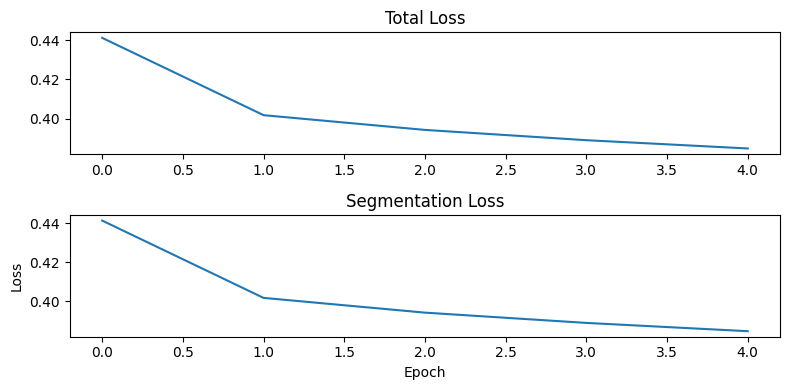

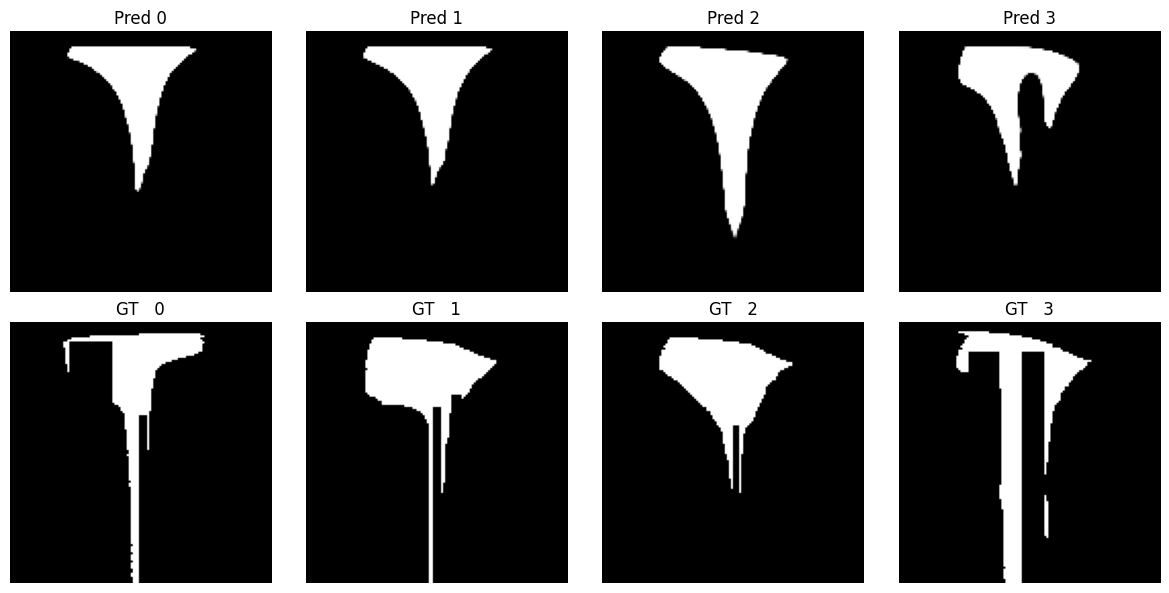

100%|██████████| 1651/1651 [07:05<00:00,  3.88it/s]


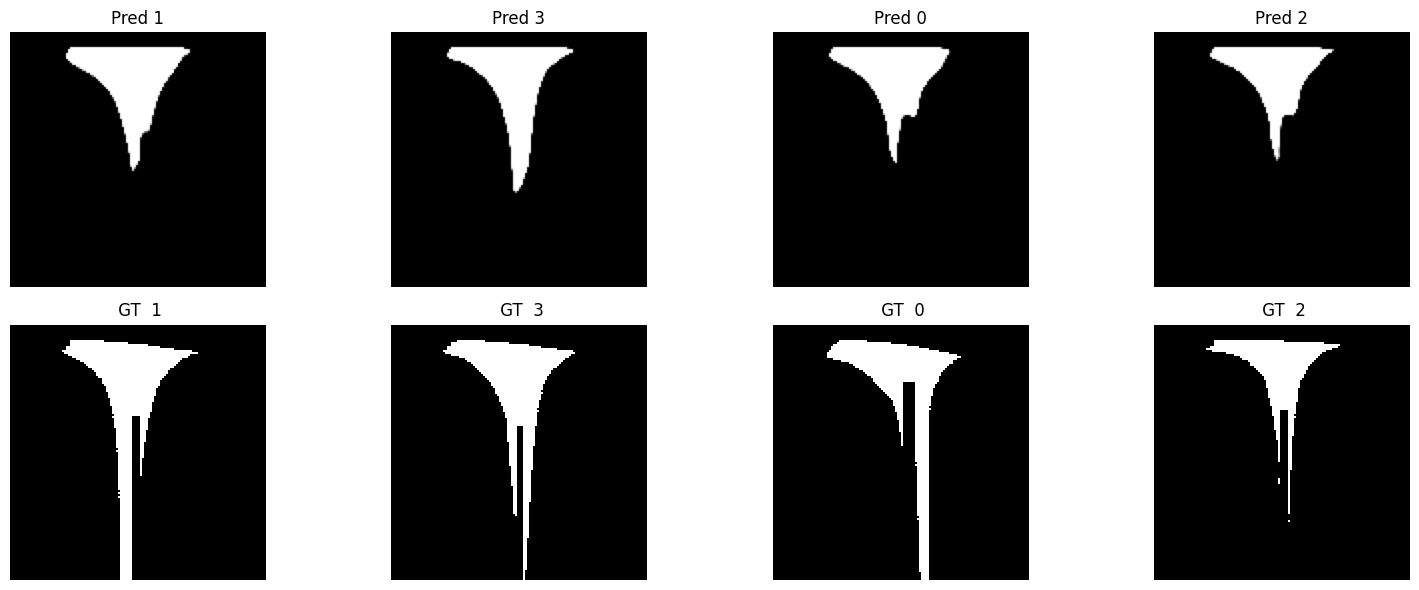

Epoch 4 val results {'pixel_acc': np.float32(0.9468572), 'iou': np.float32(0.61470515), 'dice': np.float32(0.75296), 'precision': np.float32(0.79319346), 'recall': np.float32(0.7447054)}


100%|██████████| 1650/1650 [16:56<00:00,  1.62it/s]


Segmentation 006, Loss: 0.3817


100%|██████████| 1650/1650 [14:56<00:00,  1.84it/s]


Segmentation 007, Loss: 0.3778


...

Segmentation 008, Loss: 0.3736


100%|██████████| 1650/1650 [16:45<00:00,  1.64it/s]


Segmentation 009, Loss: 0.3679


100%|██████████| 1650/1650 [14:26<00:00,  1.90it/s]


Segmentation 010, Loss: 0.3644


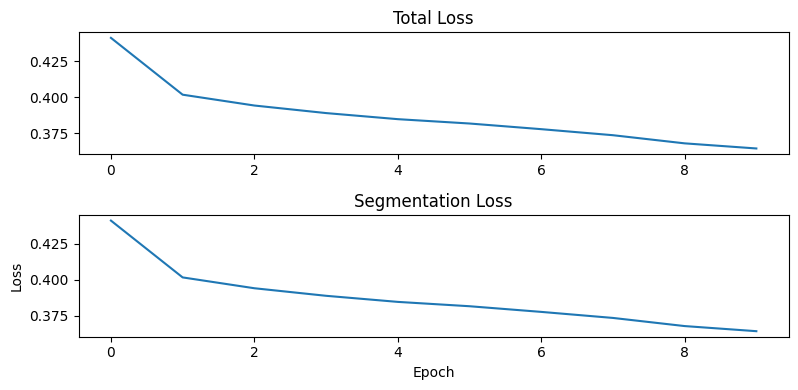

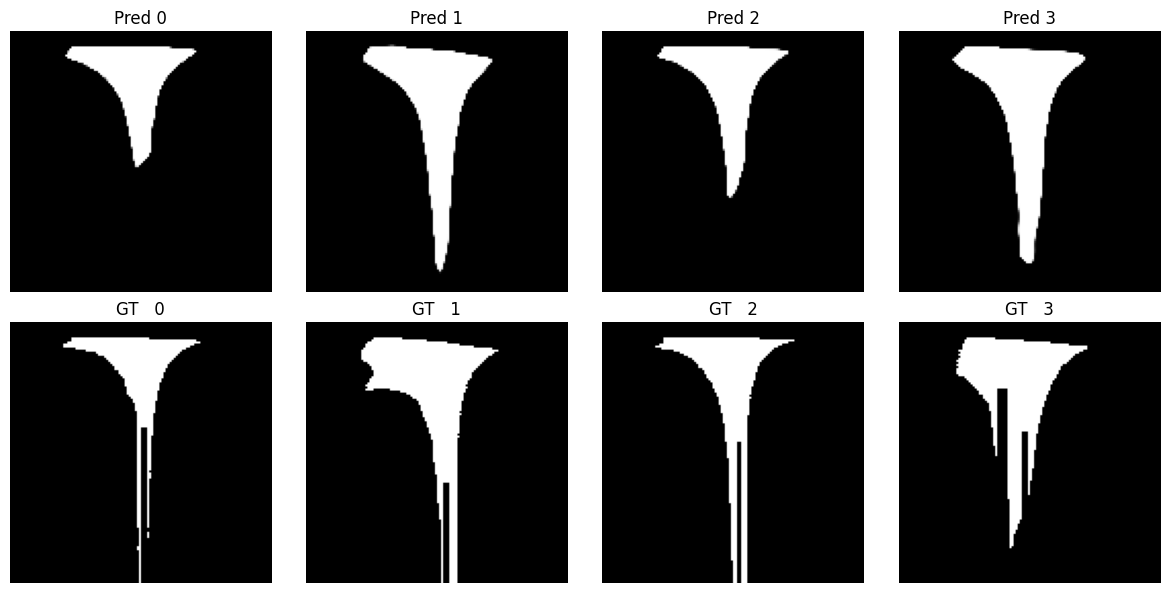

100%|██████████| 1651/1651 [06:43<00:00,  4.09it/s]


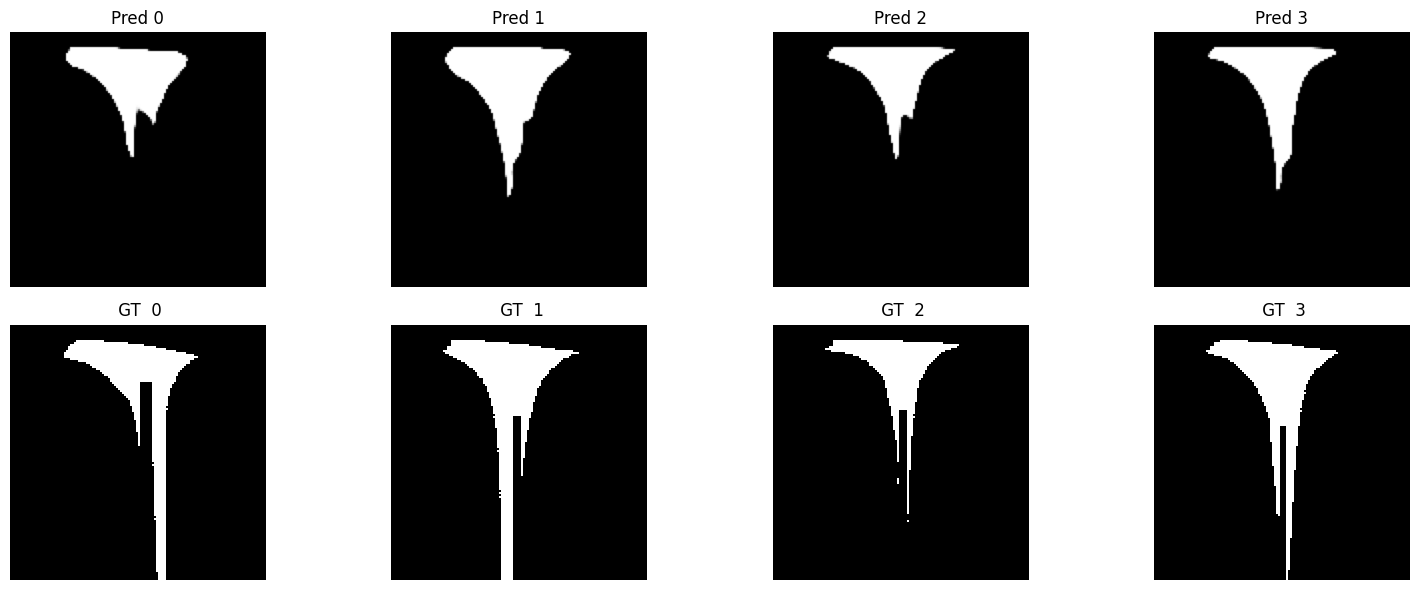

Epoch 9 val results {'pixel_acc': np.float32(0.9503376), 'iou': np.float32(0.6370707), 'dice': np.float32(0.76991373), 'precision': np.float32(0.80429196), 'recall': np.float32(0.76380956)}


100%|██████████| 1650/1650 [16:20<00:00,  1.68it/s]


Segmentation 011, Loss: 0.3605


100%|██████████| 1650/1650 [14:16<00:00,  1.93it/s]


Segmentation 012, Loss: 0.3562


...

Segmentation 013, Loss: 0.3544


100%|██████████| 1650/1650 [14:53<00:00,  1.85it/s]


Segmentation 014, Loss: 0.3517


100%|██████████| 1650/1650 [15:44<00:00,  1.75it/s] 


Segmentation 015, Loss: 0.3492


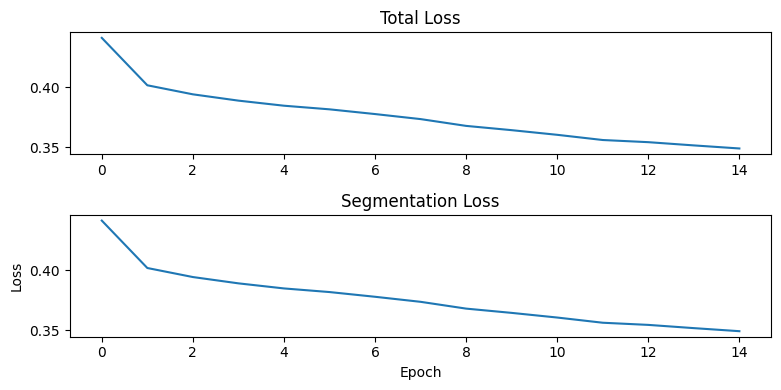

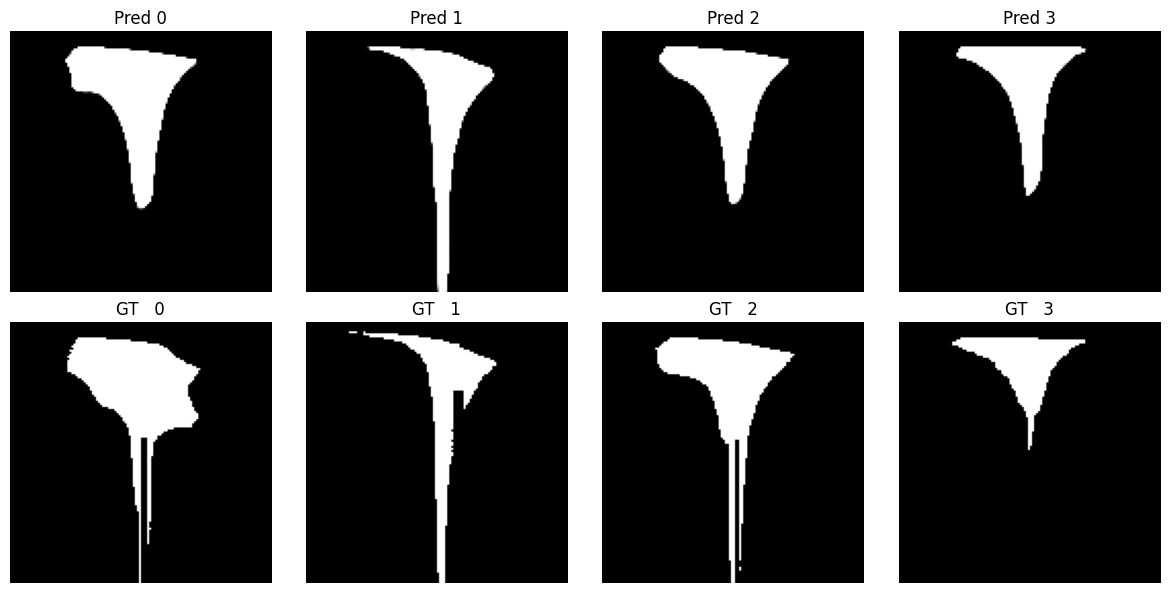

100%|██████████| 1651/1651 [06:10<00:00,  4.45it/s]


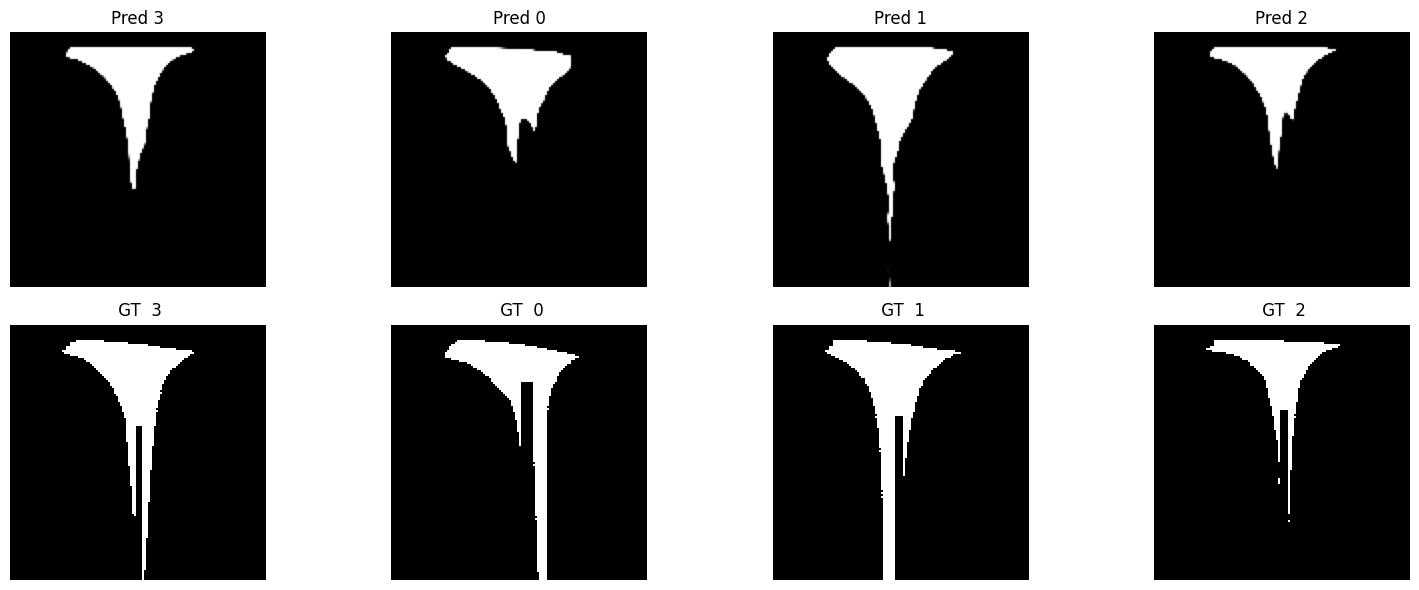

Epoch 14 val results {'pixel_acc': np.float32(0.9524618), 'iou': np.float32(0.6483668), 'dice': np.float32(0.7777131), 'precision': np.float32(0.82376426), 'recall': np.float32(0.7603123)}


100%|██████████| 1650/1650 [17:15<00:00,  1.59it/s]


Segmentation 016, Loss: 0.3467


100%|██████████| 1650/1650 [15:31<00:00,  1.77it/s]


Segmentation 017, Loss: 0.3444


...

Segmentation 018, Loss: 0.3437


100%|██████████| 1650/1650 [14:41<00:00,  1.87it/s]


Segmentation 019, Loss: 0.3408


100%|██████████| 1650/1650 [17:01<00:00,  1.62it/s]


Segmentation 020, Loss: 0.3398


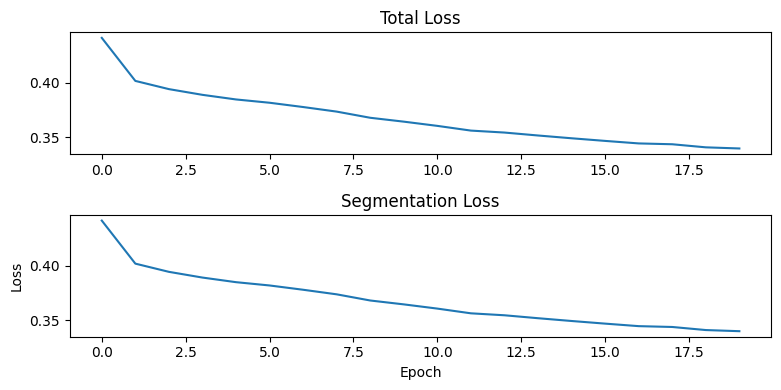

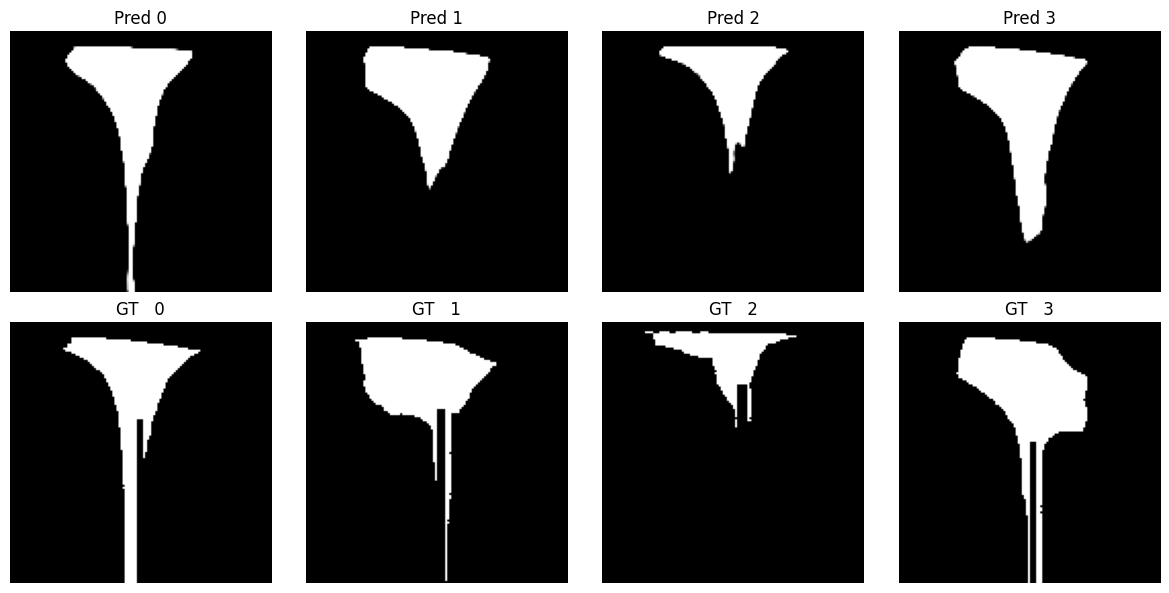

100%|██████████| 1651/1651 [06:23<00:00,  4.30it/s]


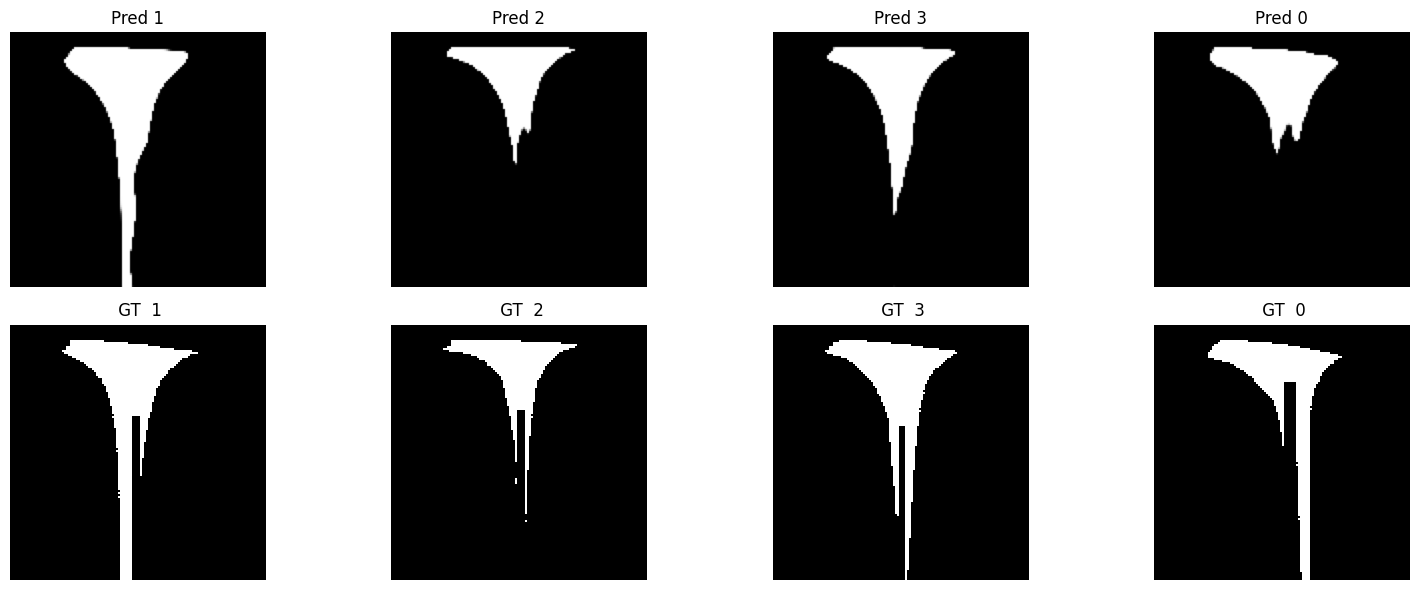

Epoch 19 val results {'pixel_acc': np.float32(0.95277333), 'iou': np.float32(0.657487), 'dice': np.float32(0.78462183), 'precision': np.float32(0.8061186), 'recall': np.float32(0.7896145)}


100%|██████████| 1650/1650 [17:12<00:00,  1.60it/s]


Segmentation 021, Loss: 0.3380


100%|██████████| 1650/1650 [15:44<00:00,  1.75it/s]


Segmentation 022, Loss: 0.3364


...

Segmentation 023, Loss: 0.3353


100%|██████████| 1650/1650 [13:58<00:00,  1.97it/s]


Segmentation 024, Loss: 0.3335


100%|██████████| 1650/1650 [17:18<00:00,  1.59it/s]


Segmentation 025, Loss: 0.3315


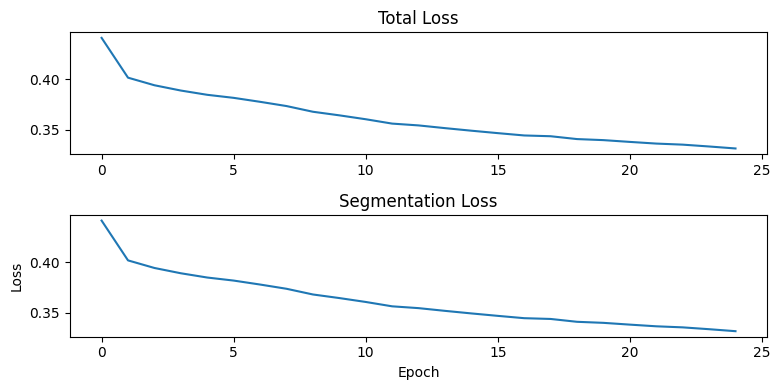

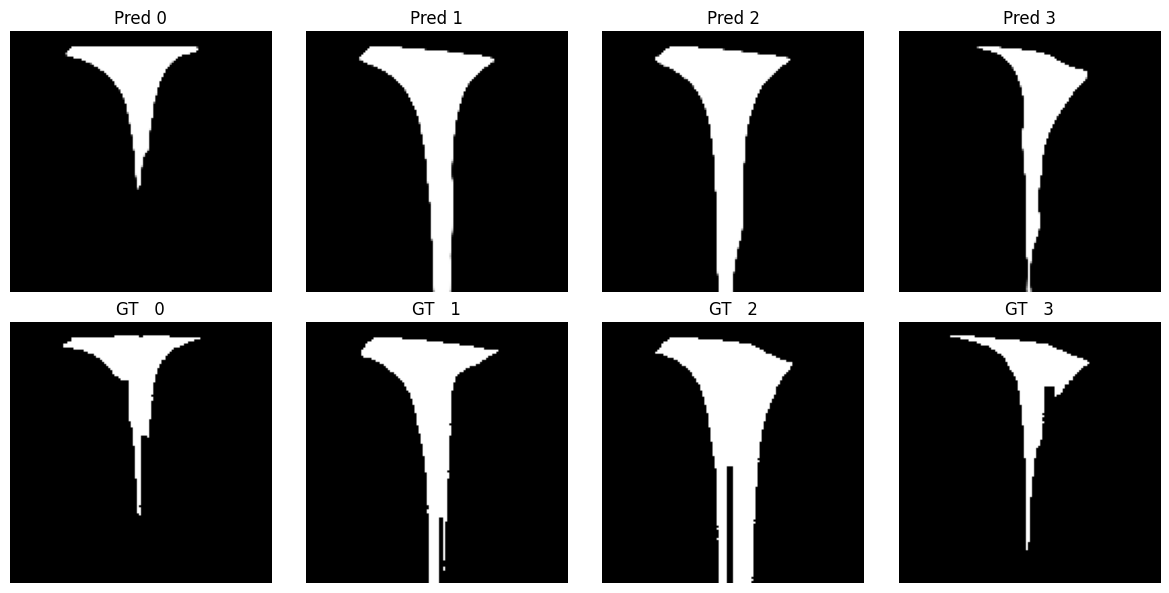

100%|██████████| 1651/1651 [06:19<00:00,  4.35it/s]


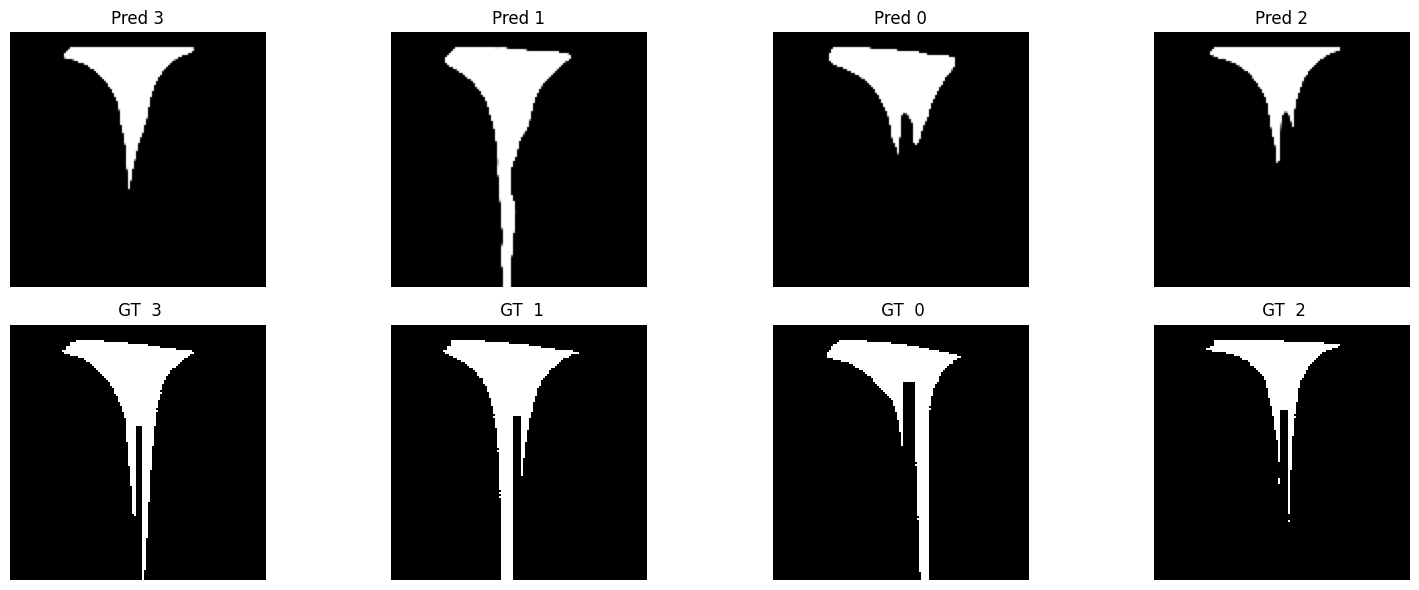

Epoch 24 val results {'pixel_acc': np.float32(0.9539553), 'iou': np.float32(0.66232085), 'dice': np.float32(0.78800166), 'precision': np.float32(0.8161458), 'recall': np.float32(0.7865535)}


100%|██████████| 1650/1650 [17:07<00:00,  1.61it/s]


Segmentation 026, Loss: 0.3297


100%|██████████| 1650/1650 [15:14<00:00,  1.80it/s]


Segmentation 027, Loss: 0.3287


...

Segmentation 028, Loss: 0.3276


100%|██████████| 1650/1650 [13:15<00:00,  2.07it/s]


Segmentation 029, Loss: 0.3262


100%|██████████| 1650/1650 [17:43<00:00,  1.55it/s]


Segmentation 030, Loss: 0.3250


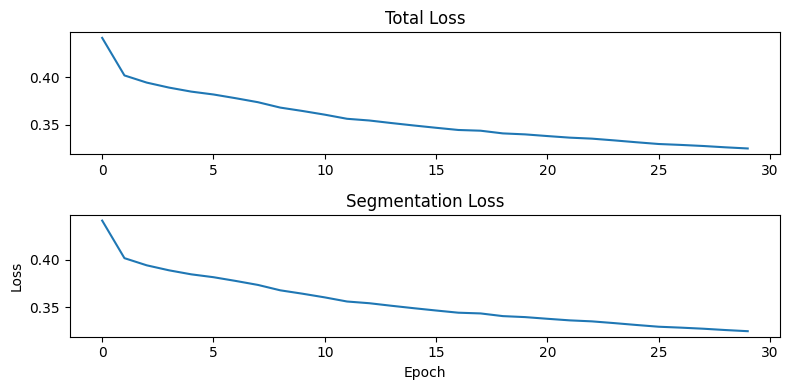

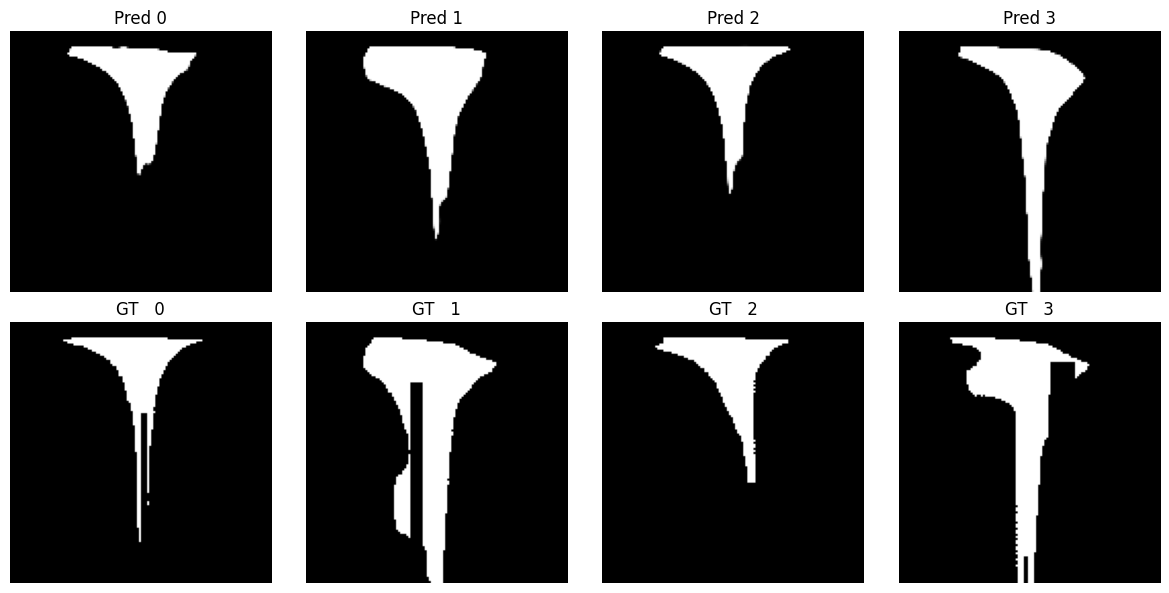

100%|██████████| 1651/1651 [06:07<00:00,  4.49it/s]


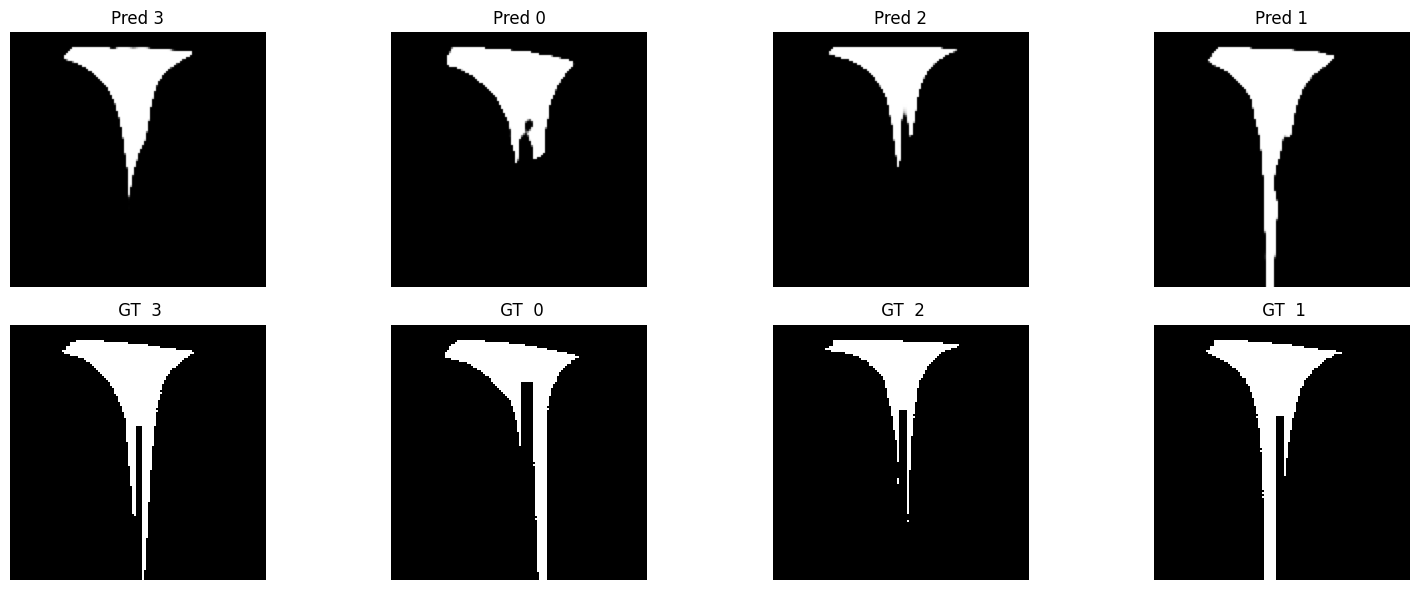

Epoch 29 val results {'pixel_acc': np.float32(0.95462763), 'iou': np.float32(0.6664317), 'dice': np.float32(0.7913016), 'precision': np.float32(0.82246375), 'recall': np.float32(0.7867275)}


100%|██████████| 1650/1650 [17:08<00:00,  1.60it/s]


Segmentation 031, Loss: 0.3234


100%|██████████| 1650/1650 [15:34<00:00,  1.77it/s]


Segmentation 032, Loss: 0.3211


...

Segmentation 033, Loss: 0.3201


100%|██████████| 1650/1650 [12:57<00:00,  2.12it/s]


Segmentation 034, Loss: 0.3183


100%|██████████| 1650/1650 [18:17<00:00,  1.50it/s]


Segmentation 035, Loss: 0.3171


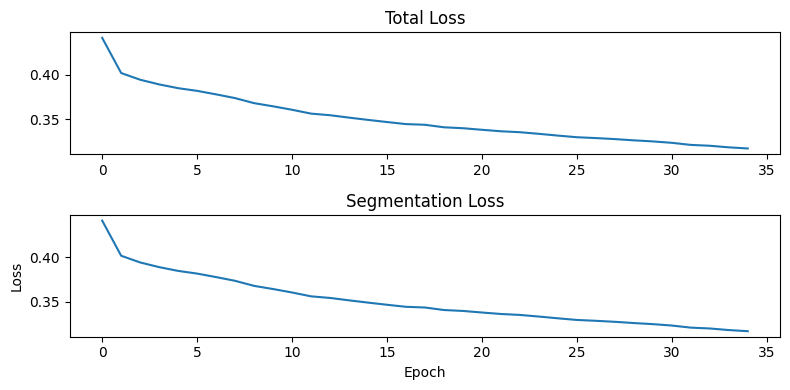

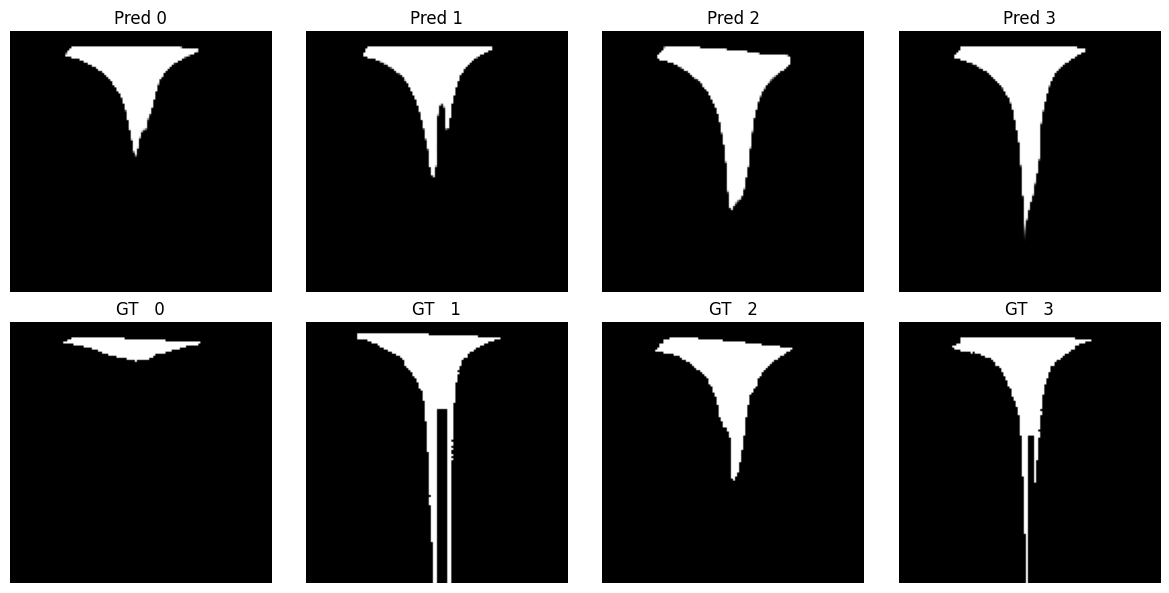

100%|██████████| 1651/1651 [06:10<00:00,  4.45it/s]


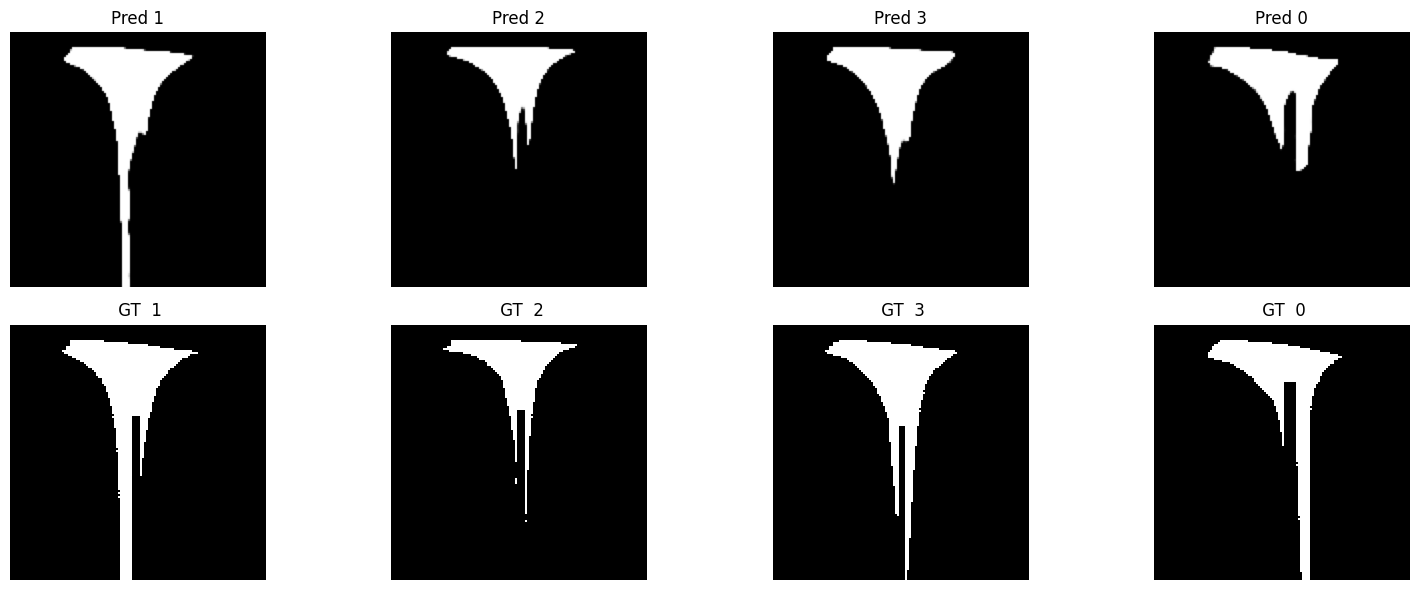

Epoch 34 val results {'pixel_acc': np.float32(0.9559268), 'iou': np.float32(0.6737611), 'dice': np.float32(0.7969605), 'precision': np.float32(0.826348), 'recall': np.float32(0.7934414)}


100%|██████████| 1650/1650 [17:32<00:00,  1.57it/s]


Segmentation 036, Loss: 0.3154


100%|██████████| 1650/1650 [15:31<00:00,  1.77it/s]


Segmentation 037, Loss: 0.3135


...

Segmentation 038, Loss: 0.3132


100%|██████████| 1650/1650 [13:32<00:00,  2.03it/s]


Segmentation 039, Loss: 0.3124


100%|██████████| 1650/1650 [19:31<00:00,  1.41it/s] 


Segmentation 040, Loss: 0.3111


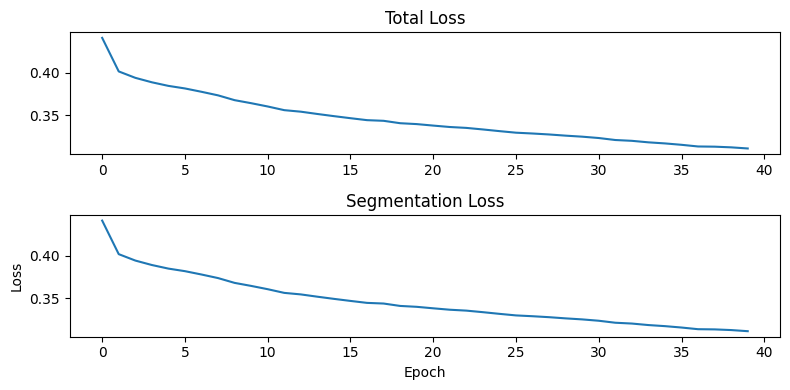

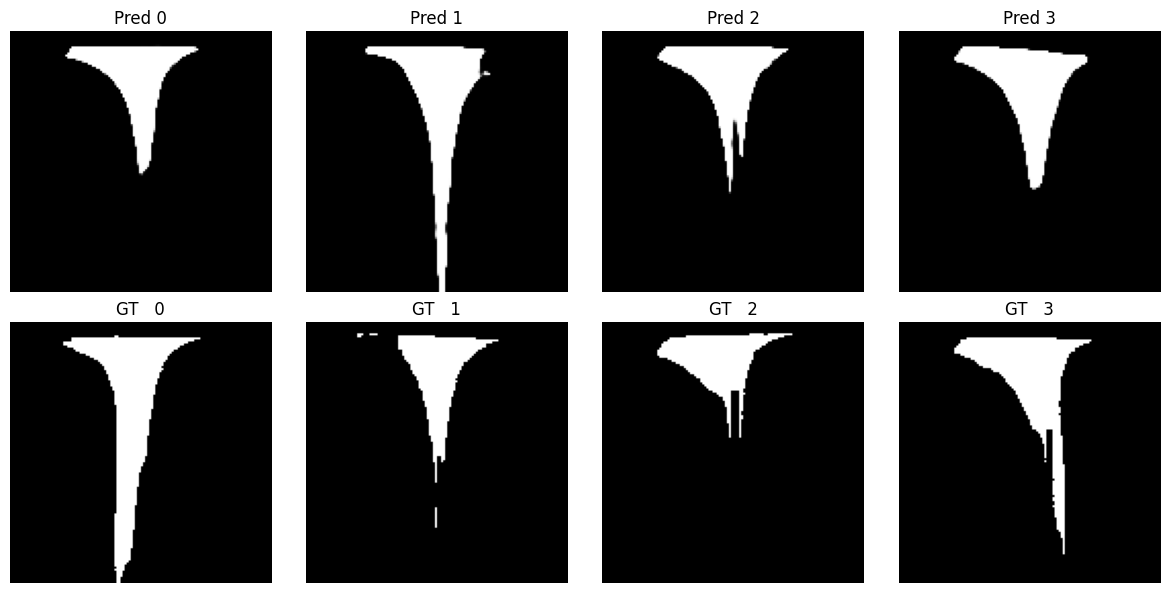

100%|██████████| 1651/1651 [06:14<00:00,  4.40it/s]


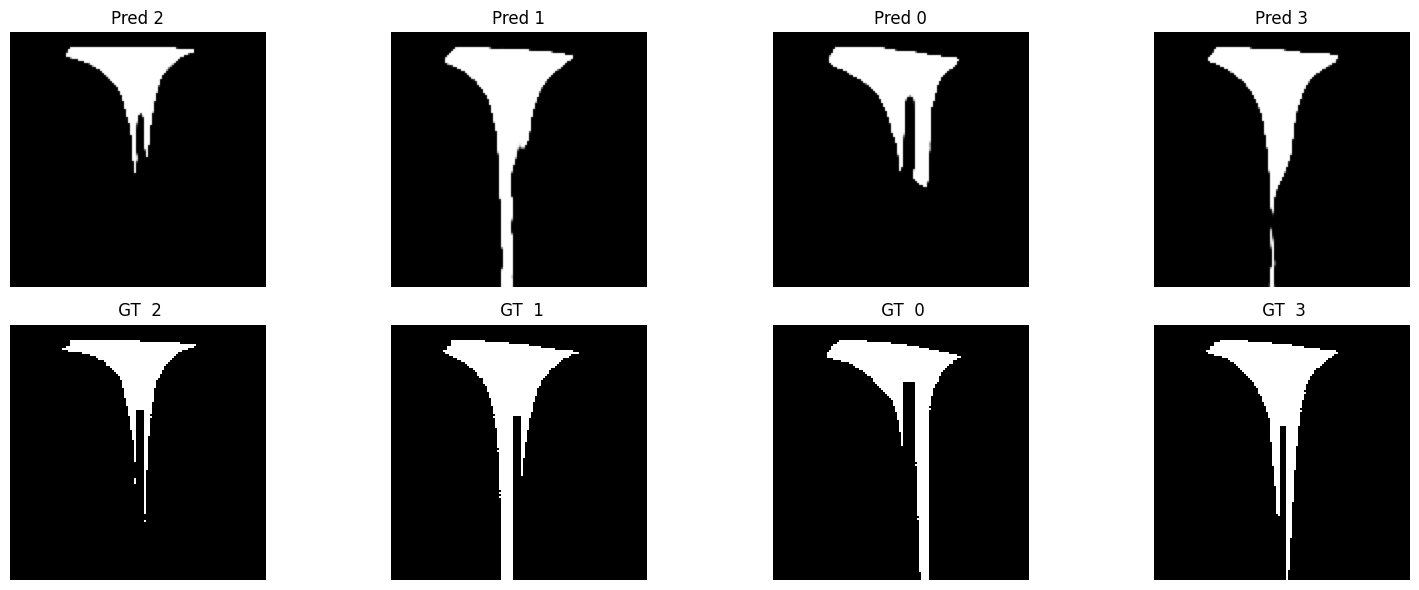

Epoch 39 val results {'pixel_acc': np.float32(0.95602465), 'iou': np.float32(0.674972), 'dice': np.float32(0.7980395), 'precision': np.float32(0.82451236), 'recall': np.float32(0.7965788)}


100%|██████████| 1650/1650 [18:18<00:00,  1.50it/s] 


Segmentation 041, Loss: 0.3087


100%|██████████| 1650/1650 [15:58<00:00,  1.72it/s]


Segmentation 042, Loss: 0.3072


...

Segmentation 043, Loss: 0.3065


100%|██████████| 1650/1650 [13:29<00:00,  2.04it/s]


Segmentation 044, Loss: 0.3052


100%|██████████| 1650/1650 [19:01<00:00,  1.45it/s]


Segmentation 045, Loss: 0.3043


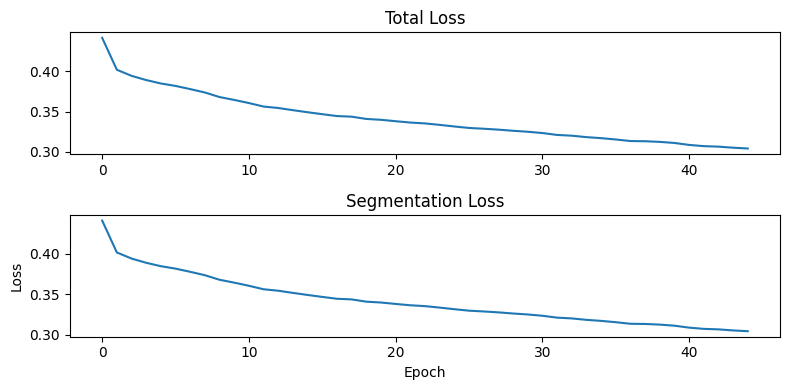

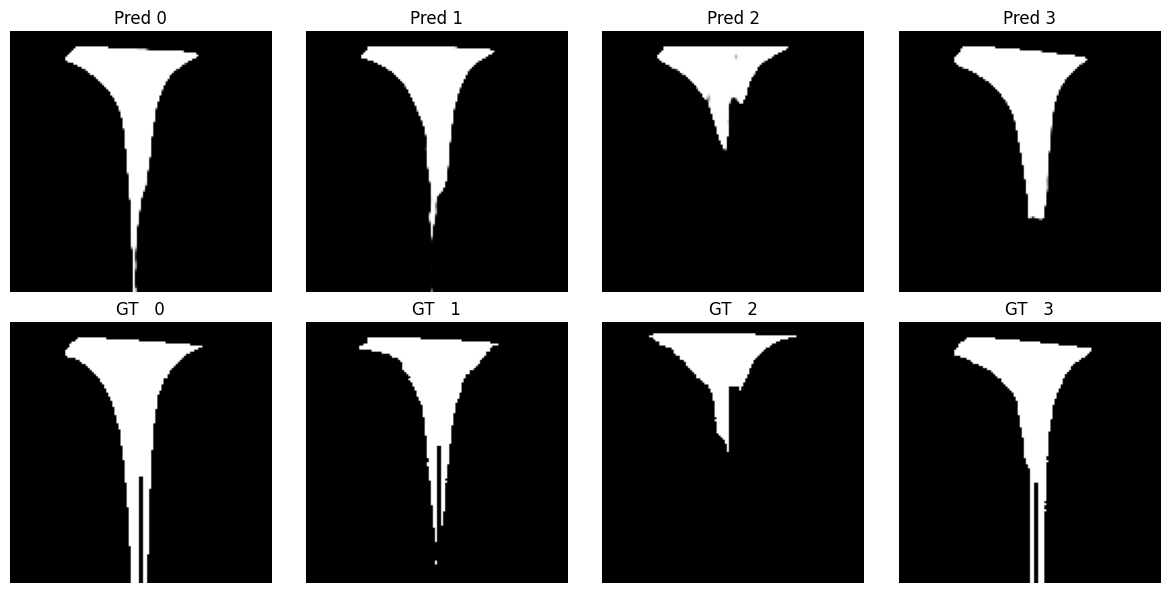

100%|██████████| 1651/1651 [06:18<00:00,  4.36it/s]


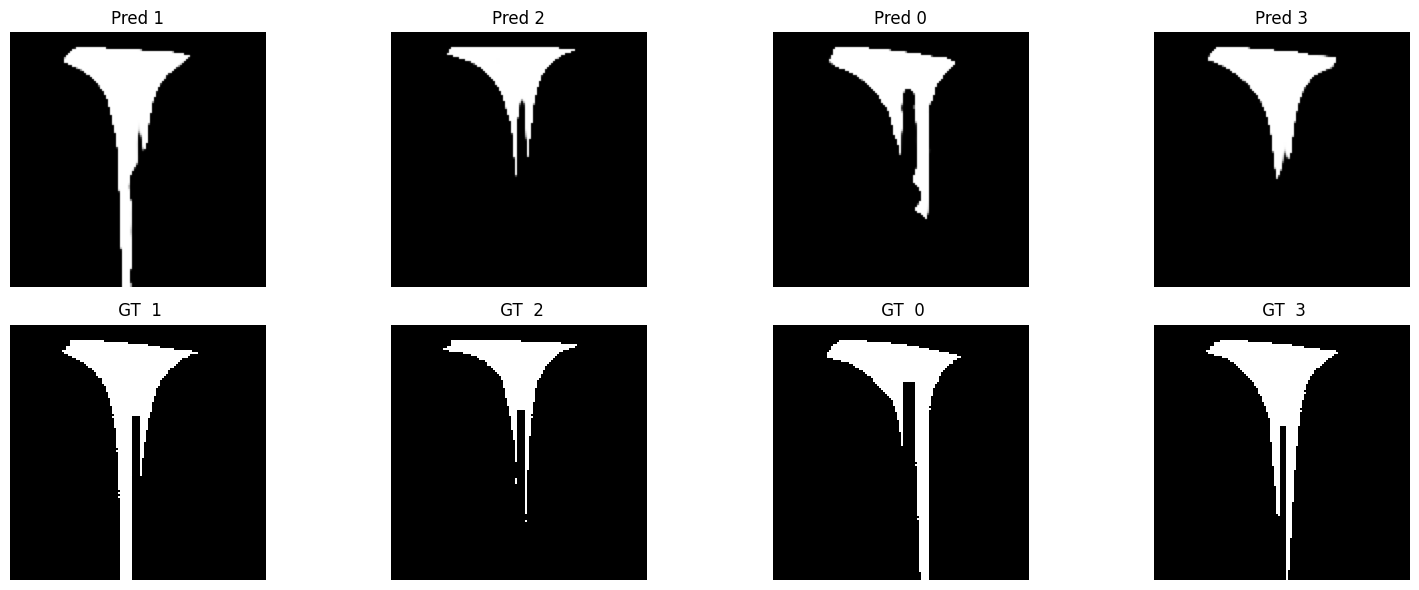

Epoch 44 val results {'pixel_acc': np.float32(0.9572664), 'iou': np.float32(0.6791432), 'dice': np.float32(0.8007706), 'precision': np.float32(0.84411), 'recall': np.float32(0.78434056)}


100%|██████████| 1650/1650 [18:07<00:00,  1.52it/s]


Segmentation 046, Loss: 0.3027


100%|██████████| 1650/1650 [16:26<00:00,  1.67it/s]


Segmentation 047, Loss: 0.3016


...

Segmentation 048, Loss: 0.3005


100%|██████████| 1650/1650 [14:09<00:00,  1.94it/s]


Segmentation 049, Loss: 0.2992


100%|██████████| 1650/1650 [19:13<00:00,  1.43it/s]


Segmentation 050, Loss: 0.3000


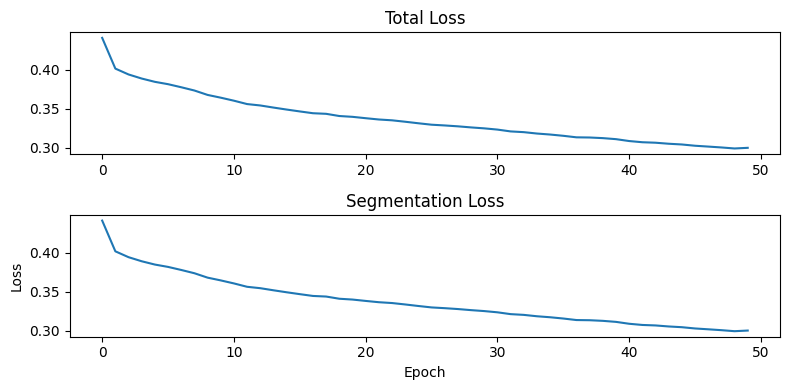

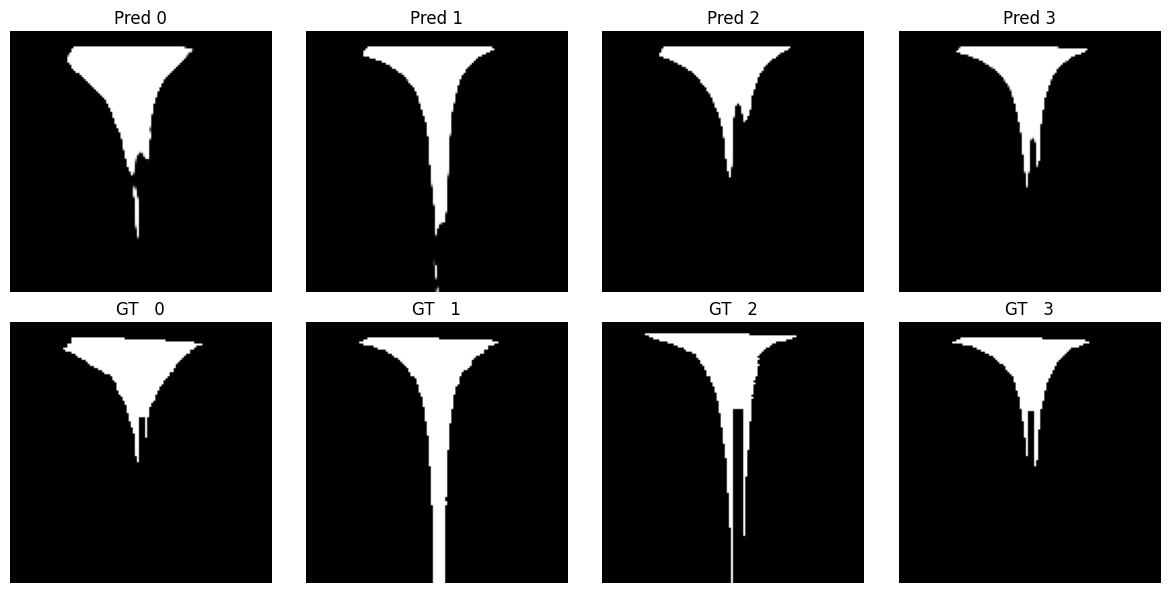

100%|██████████| 1651/1651 [06:17<00:00,  4.37it/s]


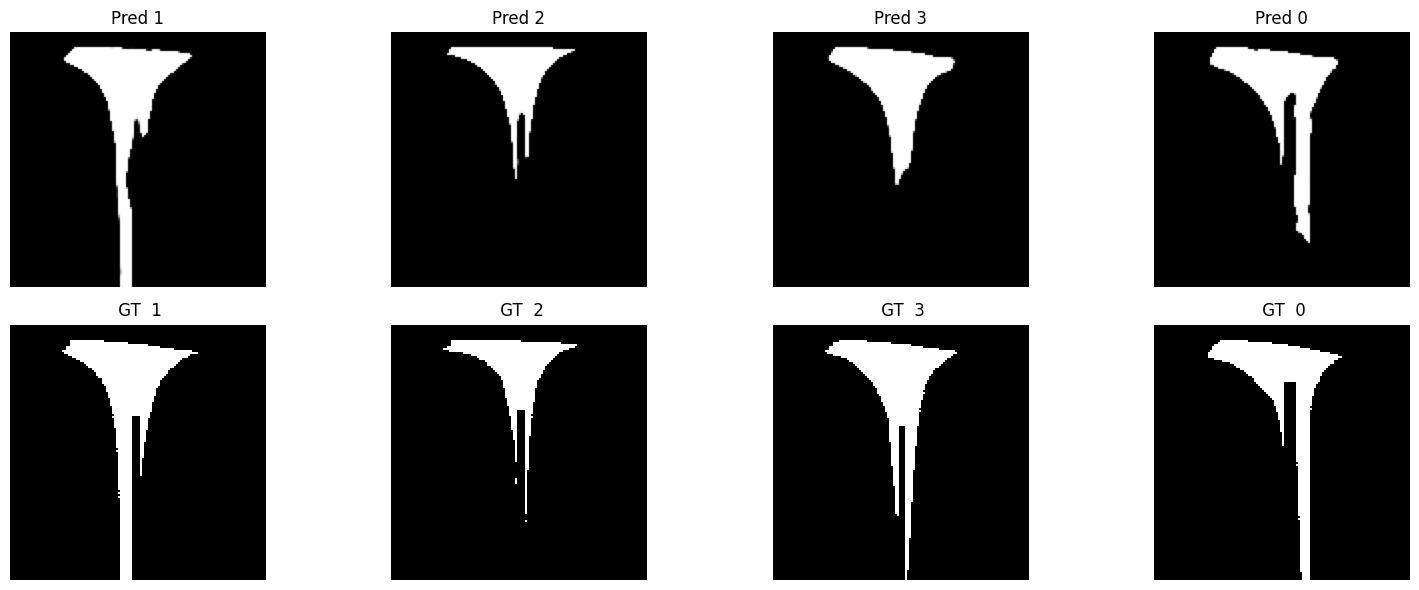

Epoch 49 val results {'pixel_acc': np.float32(0.95665807), 'iou': np.float32(0.6844119), 'dice': np.float32(0.804455), 'precision': np.float32(0.81413263), 'recall': np.float32(0.8192809)}


100%|██████████| 1650/1650 [17:45<00:00,  1.55it/s]


Segmentation 051, Loss: 0.2971


100%|██████████| 1650/1650 [15:53<00:00,  1.73it/s]


Segmentation 052, Loss: 0.2963


...

Segmentation 053, Loss: 0.2950


100%|██████████| 1650/1650 [13:02<00:00,  2.11it/s]


Segmentation 054, Loss: 0.2935


100%|██████████| 1650/1650 [18:56<00:00,  1.45it/s]


Segmentation 055, Loss: 0.2927


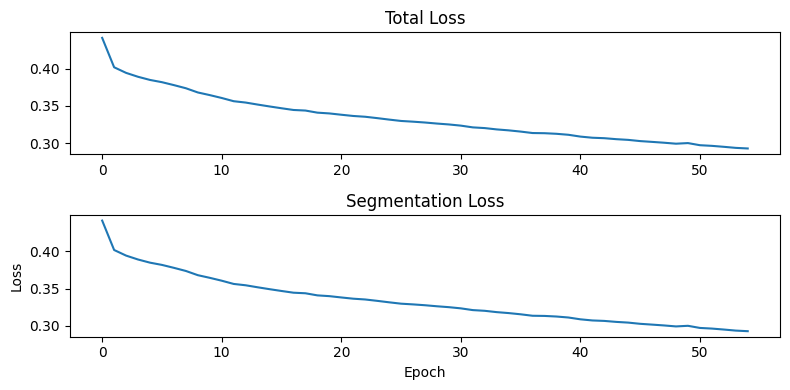

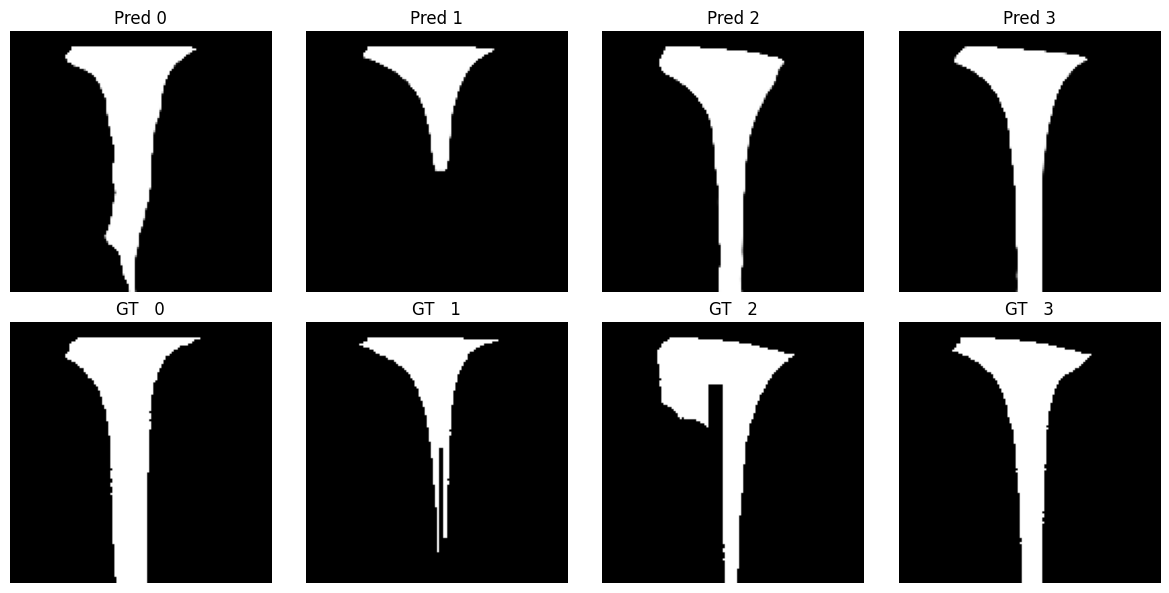

100%|██████████| 1651/1651 [06:11<00:00,  4.44it/s]


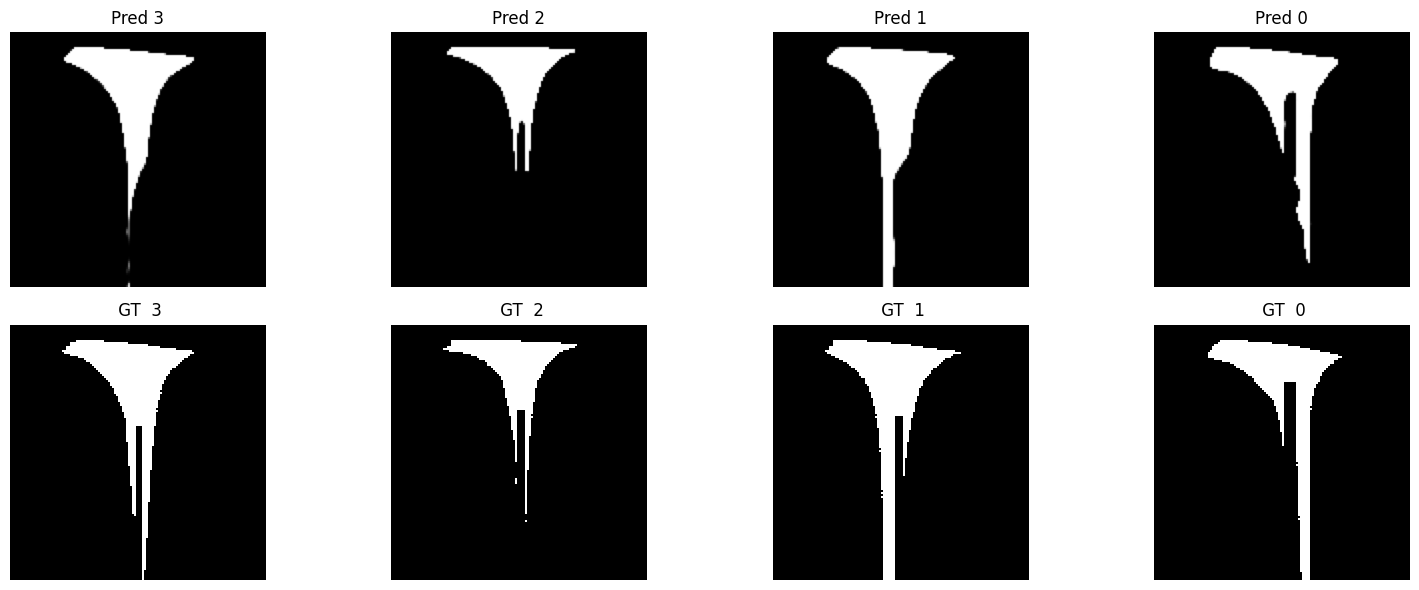

Epoch 54 val results {'pixel_acc': np.float32(0.9566285), 'iou': np.float32(0.6854238), 'dice': np.float32(0.8054513), 'precision': np.float32(0.8122789), 'recall': np.float32(0.8227653)}


100%|██████████| 1650/1650 [17:35<00:00,  1.56it/s]


Segmentation 056, Loss: 0.2914


100%|██████████| 1650/1650 [15:57<00:00,  1.72it/s]


Segmentation 057, Loss: 0.2905


...

Segmentation 058, Loss: 0.2886


100%|██████████| 1650/1650 [14:26<00:00,  1.90it/s]


Segmentation 059, Loss: 0.2882


100%|██████████| 1650/1650 [19:35<00:00,  1.40it/s]


Segmentation 060, Loss: 0.2869


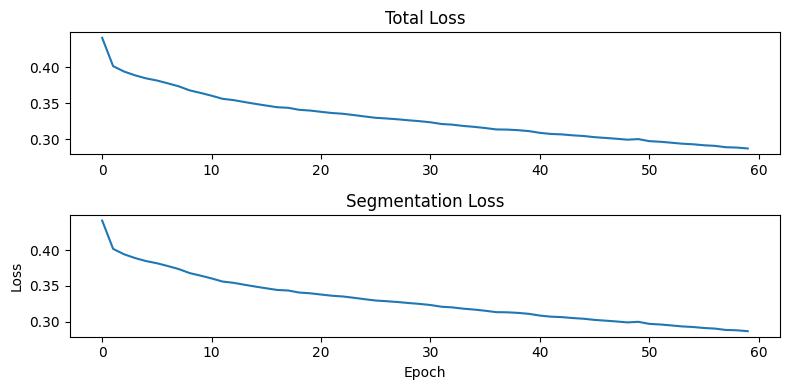

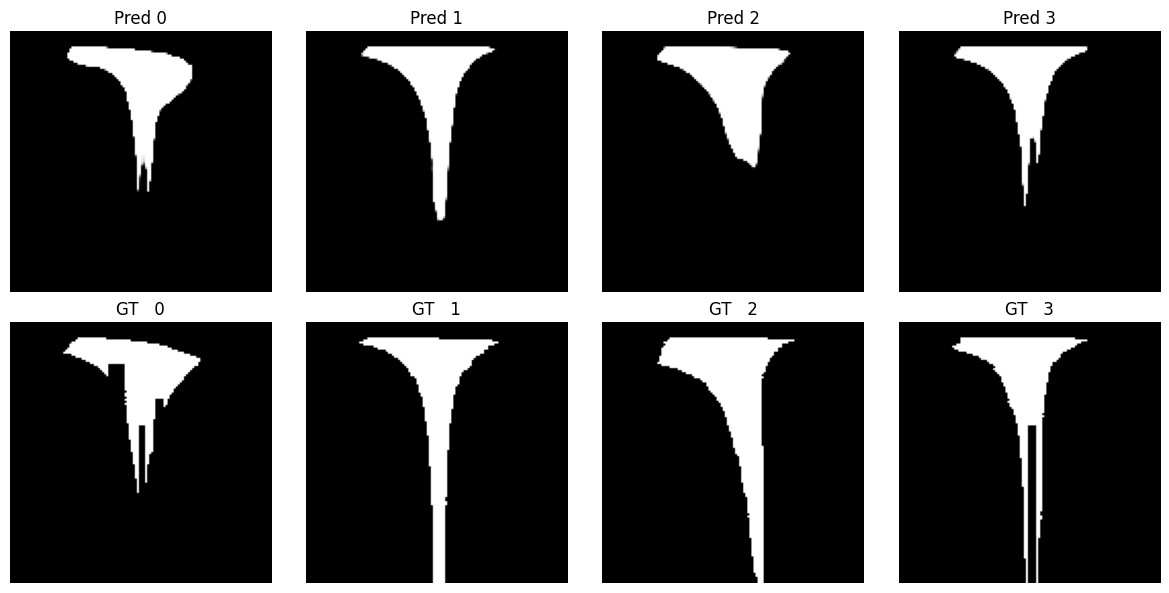

100%|██████████| 1651/1651 [06:21<00:00,  4.32it/s]


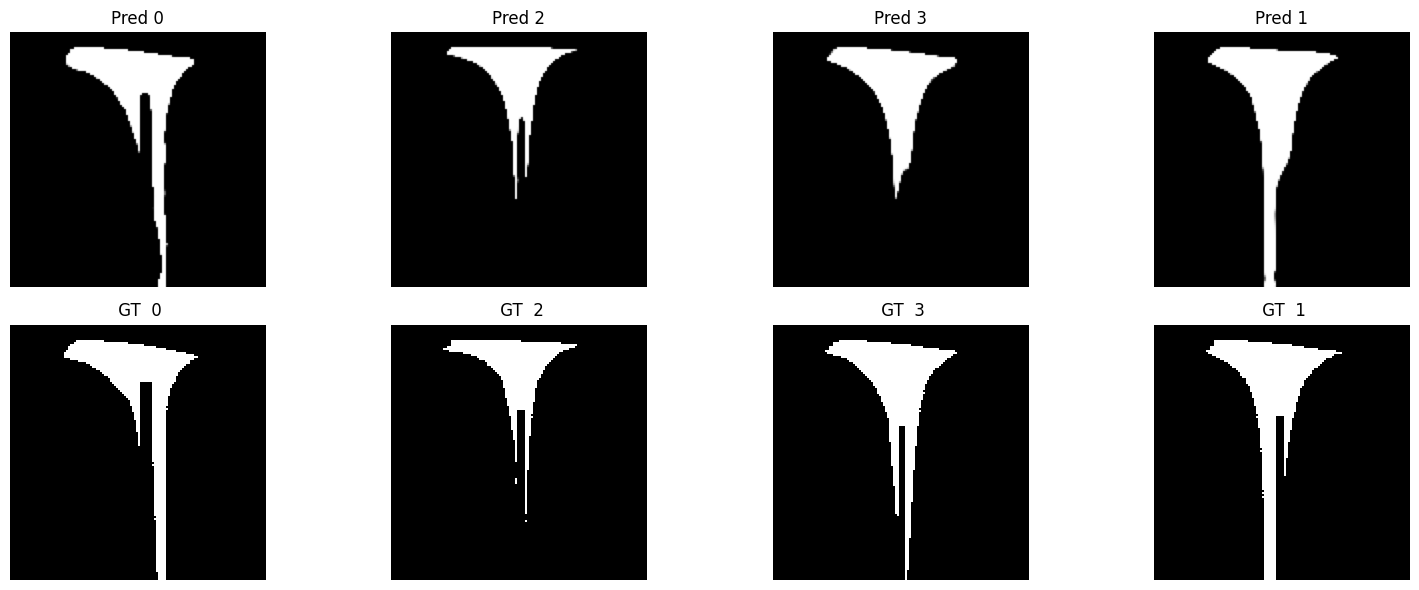

Epoch 59 val results {'pixel_acc': np.float32(0.958082), 'iou': np.float32(0.68706584), 'dice': np.float32(0.8066648), 'precision': np.float32(0.8381851), 'recall': np.float32(0.8004818)}


100%|██████████| 1650/1650 [18:10<00:00,  1.51it/s] 


Segmentation 061, Loss: 0.2855


100%|██████████| 1650/1650 [16:49<00:00,  1.63it/s]


Segmentation 062, Loss: 0.2845


...

Segmentation 063, Loss: 0.2843


100%|██████████| 1650/1650 [14:30<00:00,  1.90it/s]


Segmentation 064, Loss: 0.2826


100%|██████████| 1650/1650 [19:38<00:00,  1.40it/s]


Segmentation 065, Loss: 0.2817


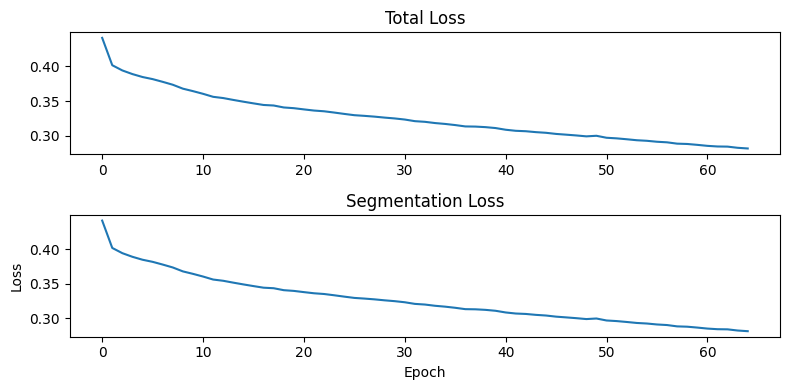

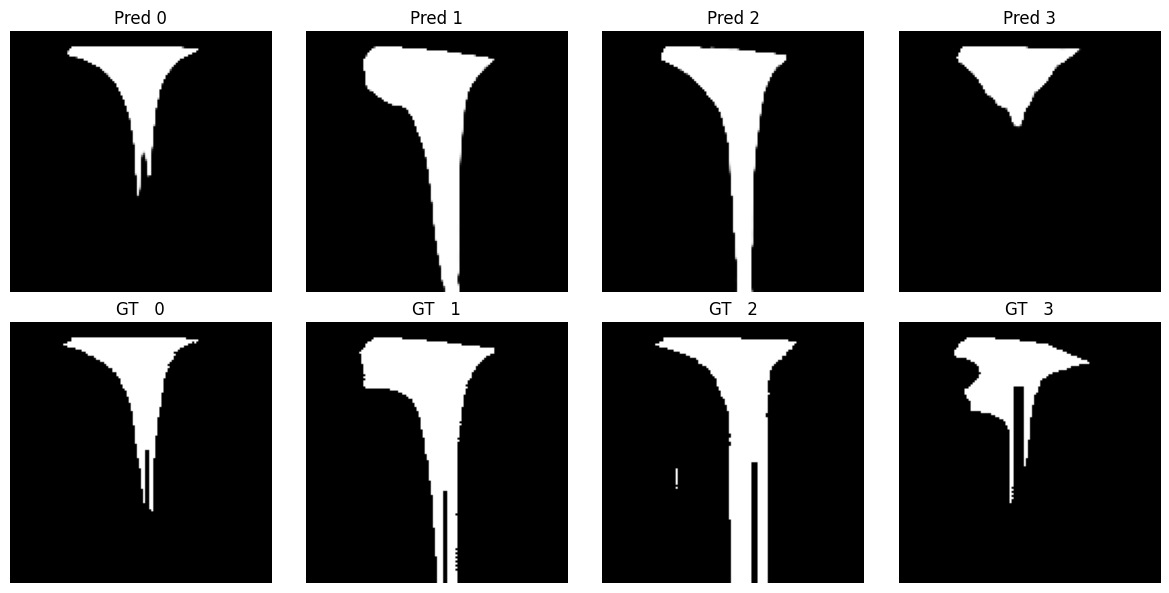

100%|██████████| 1651/1651 [06:15<00:00,  4.40it/s]


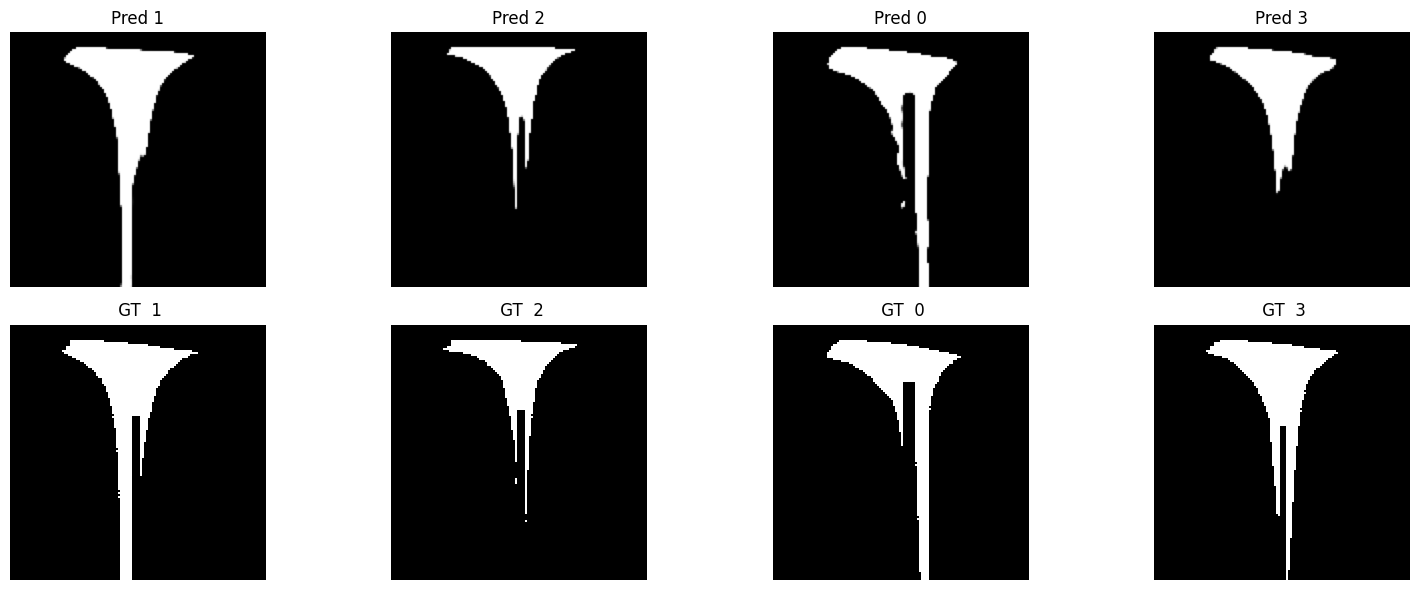

Epoch 64 val results {'pixel_acc': np.float32(0.9579819), 'iou': np.float32(0.6869526), 'dice': np.float32(0.8062532), 'precision': np.float32(0.8381009), 'recall': np.float32(0.799939)}


100%|██████████| 1650/1650 [18:13<00:00,  1.51it/s]


Segmentation 066, Loss: 0.2798


100%|██████████| 1650/1650 [12:24<00:00,  2.22it/s]


Segmentation 067, Loss: 0.2798


...

Segmentation 068, Loss: 0.2789


100%|██████████| 1650/1650 [10:03<00:00,  2.73it/s]


Segmentation 069, Loss: 0.2767


100%|██████████| 1650/1650 [06:41<00:00,  4.11it/s]


Segmentation 070, Loss: 0.2754


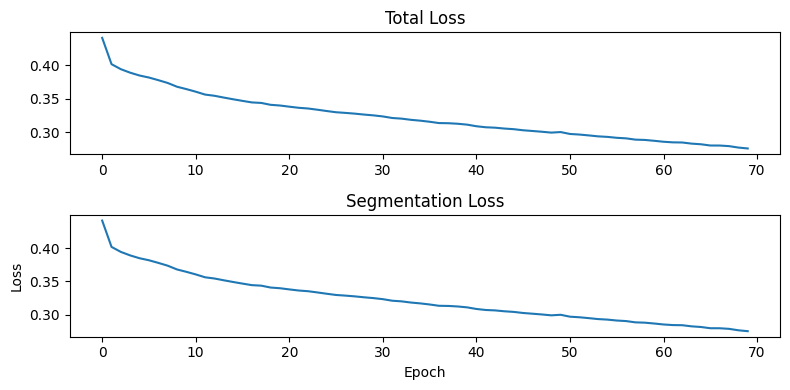

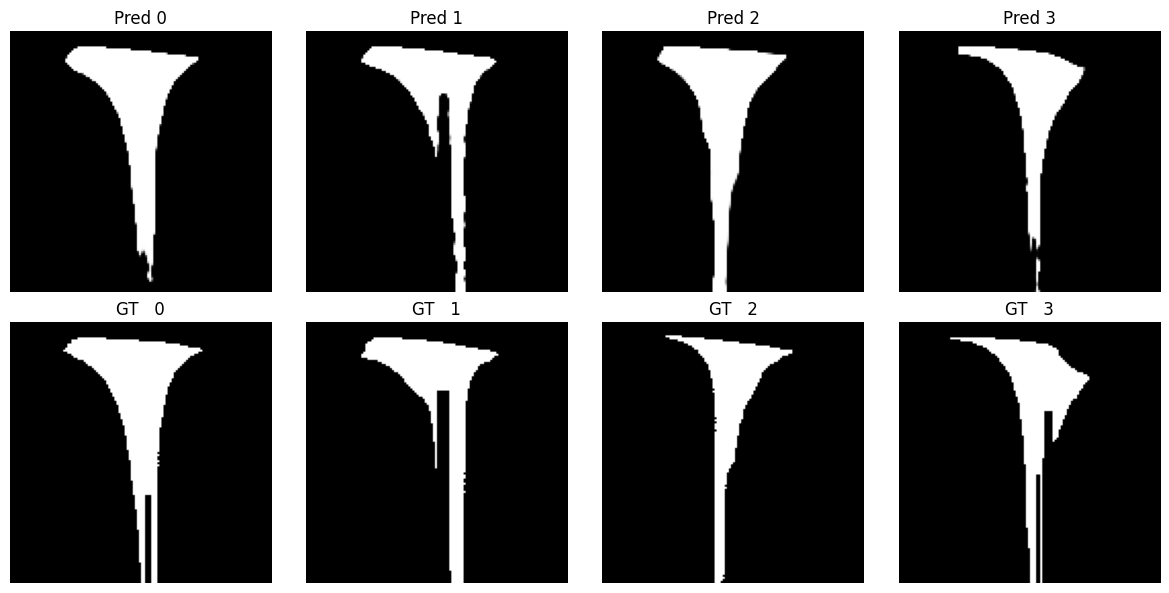

100%|██████████| 1651/1651 [02:51<00:00,  9.63it/s]


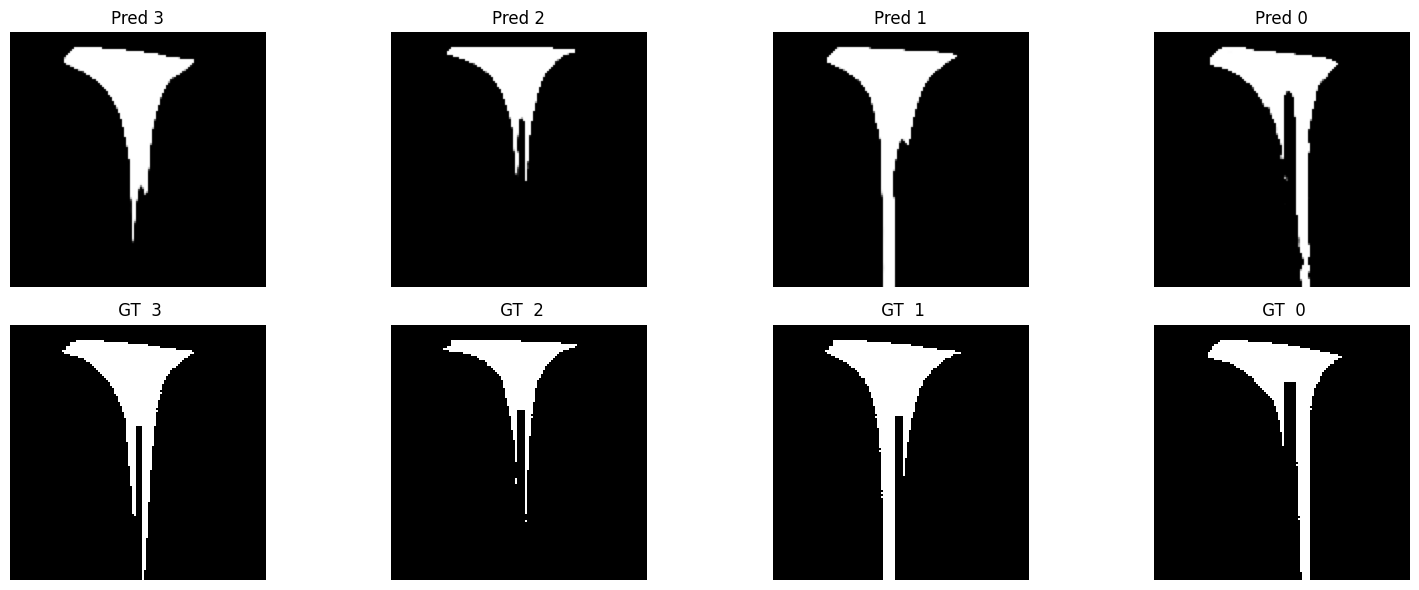

Epoch 69 val results {'pixel_acc': np.float32(0.9579647), 'iou': np.float32(0.69083524), 'dice': np.float32(0.80920285), 'precision': np.float32(0.82652336), 'recall': np.float32(0.8159099)}


100%|██████████| 1650/1650 [15:17<00:00,  1.80it/s]


Segmentation 071, Loss: 0.2753


100%|██████████| 1650/1650 [15:34<00:00,  1.76it/s]


Segmentation 072, Loss: 0.2732


...

Segmentation 073, Loss: 0.2719


100%|██████████| 1650/1650 [13:58<00:00,  1.97it/s]


Segmentation 074, Loss: 0.2712


100%|██████████| 1650/1650 [14:15<00:00,  1.93it/s]


Segmentation 075, Loss: 0.2703


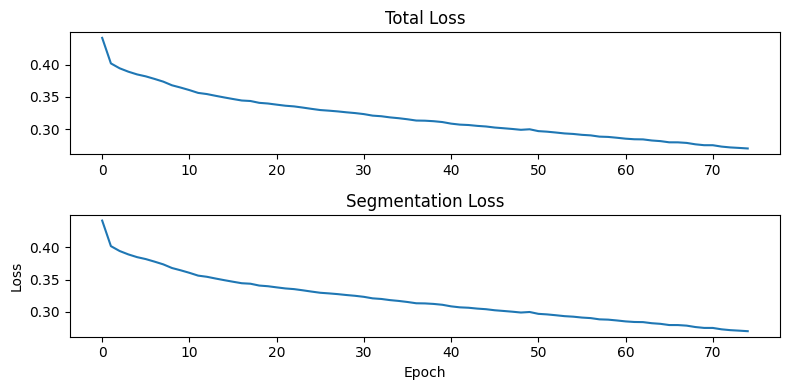

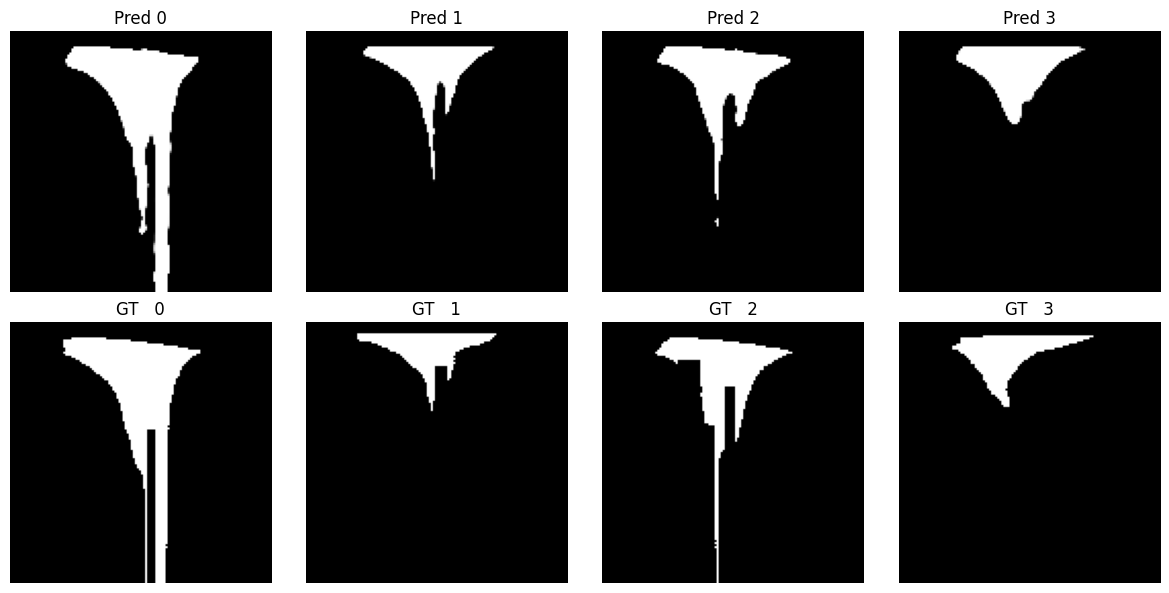

100%|██████████| 1651/1651 [06:55<00:00,  3.97it/s]


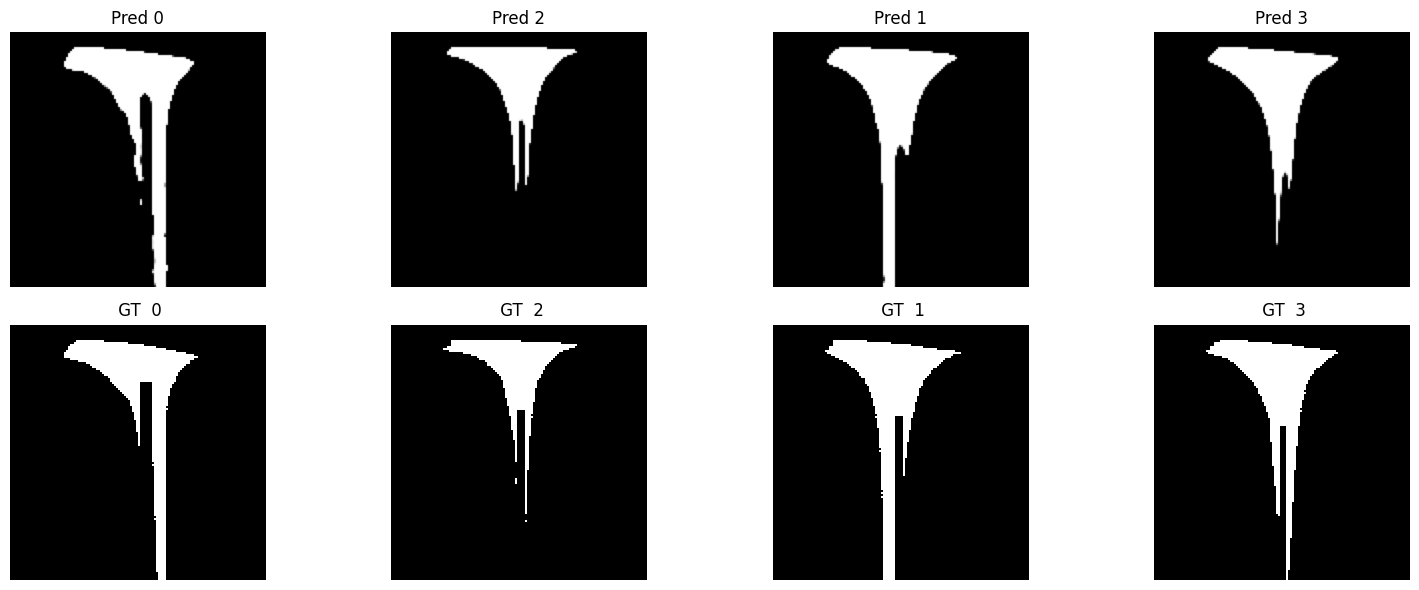

Epoch 74 val results {'pixel_acc': np.float32(0.95838857), 'iou': np.float32(0.6956302), 'dice': np.float32(0.81258416), 'precision': np.float32(0.81971955), 'recall': np.float32(0.82874715)}


100%|██████████| 1650/1650 [18:50<00:00,  1.46it/s]


Segmentation 076, Loss: 0.2693


100%|██████████| 1650/1650 [18:22<00:00,  1.50it/s]


Segmentation 077, Loss: 0.2687


...

Segmentation 078, Loss: 0.2674


100%|██████████| 1650/1650 [14:31<00:00,  1.89it/s]


Segmentation 079, Loss: 0.2667


100%|██████████| 1650/1650 [14:11<00:00,  1.94it/s]


Segmentation 080, Loss: 0.2668


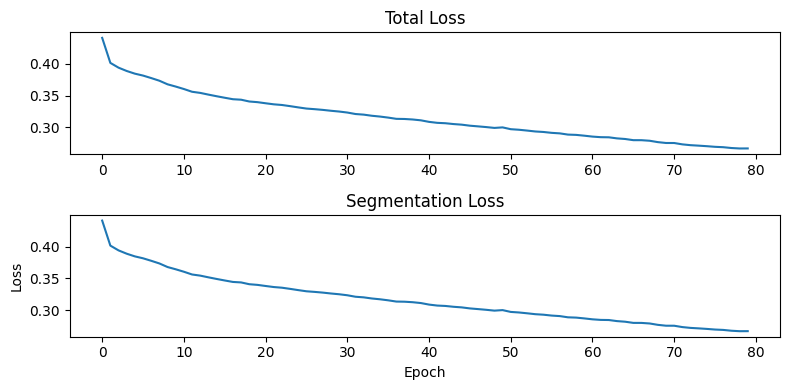

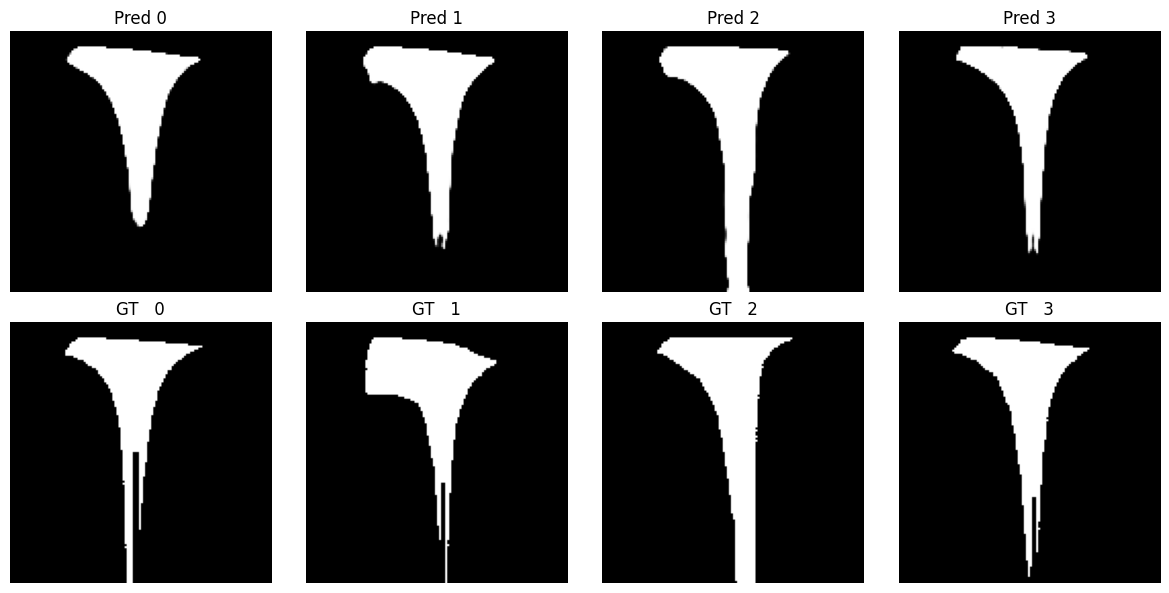

100%|██████████| 1651/1651 [06:52<00:00,  4.00it/s]


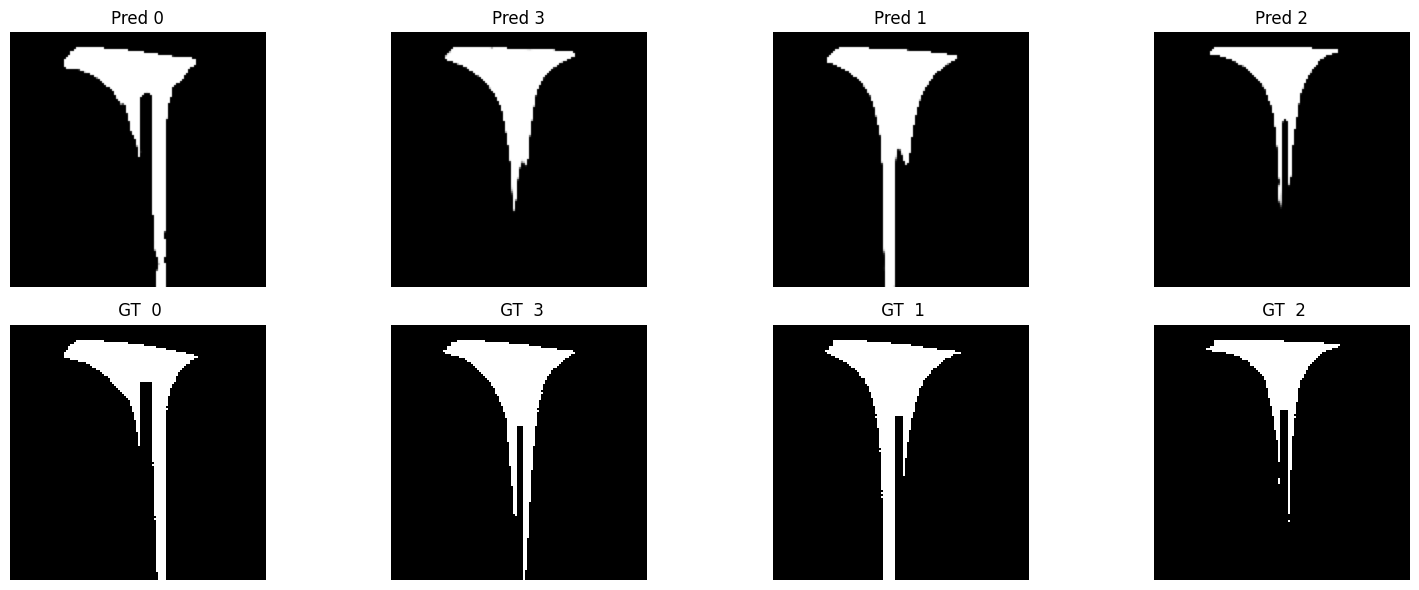

Epoch 79 val results {'pixel_acc': np.float32(0.9582347), 'iou': np.float32(0.6948334), 'dice': np.float32(0.8119468), 'precision': np.float32(0.8239444), 'recall': np.float32(0.8239739)}


100%|██████████| 1650/1650 [19:20<00:00,  1.42it/s]


Segmentation 081, Loss: 0.2651


100%|██████████| 1650/1650 [17:50<00:00,  1.54it/s]


Segmentation 082, Loss: 0.2640


...

Segmentation 083, Loss: 0.2629


100%|██████████| 1650/1650 [14:56<00:00,  1.84it/s]


Segmentation 084, Loss: 0.2631


100%|██████████| 1650/1650 [14:46<00:00,  1.86it/s]


Segmentation 085, Loss: 0.2610


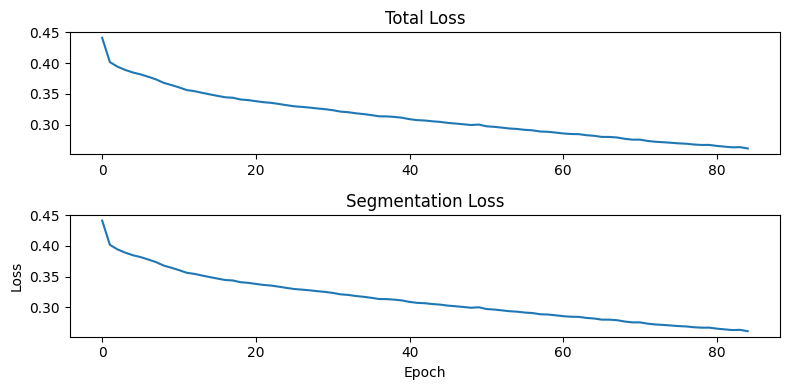

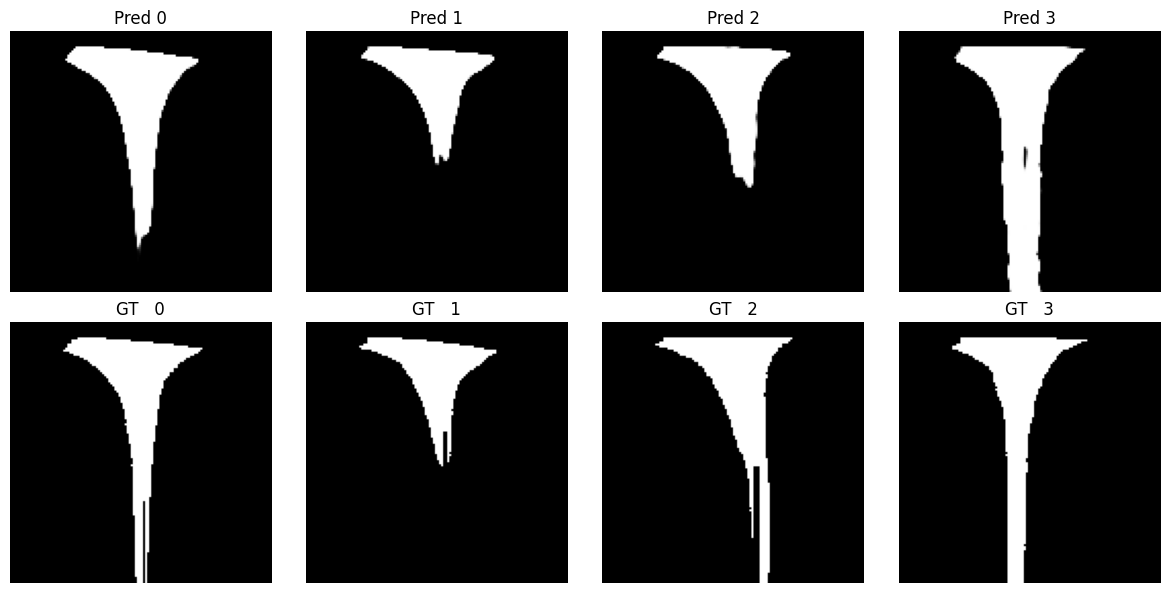

100%|██████████| 1651/1651 [06:59<00:00,  3.94it/s]


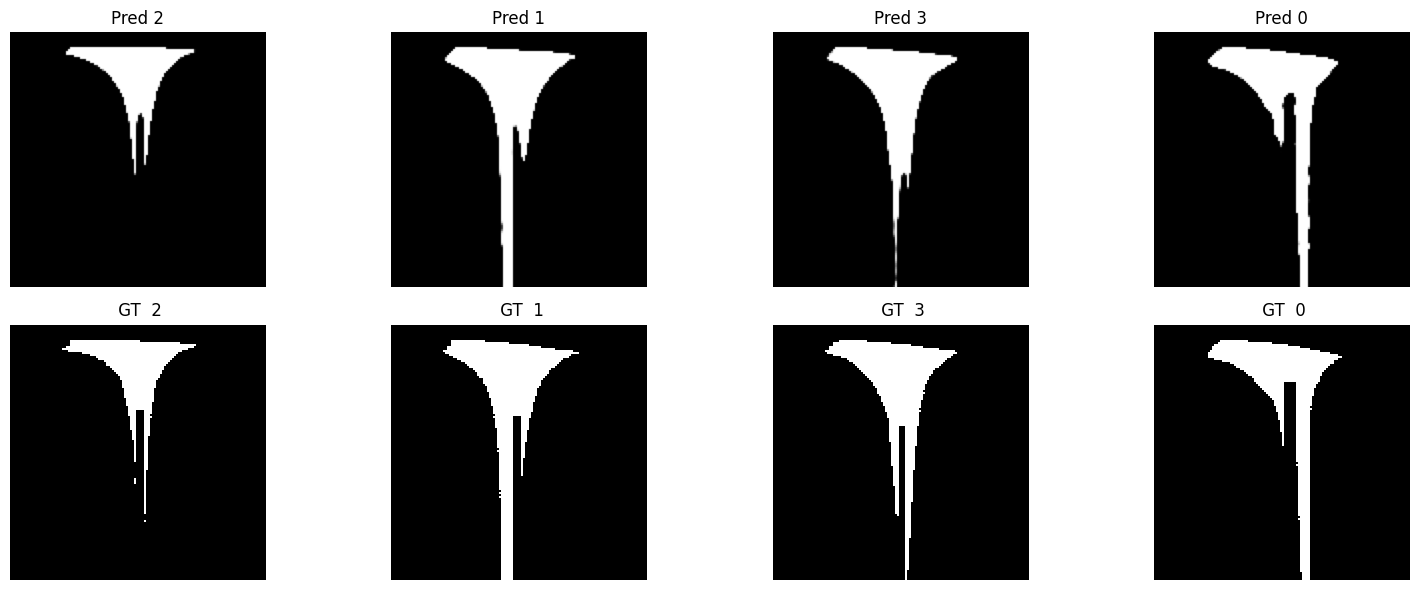

Epoch 84 val results {'pixel_acc': np.float32(0.95893824), 'iou': np.float32(0.69656235), 'dice': np.float32(0.8128549), 'precision': np.float32(0.8352715), 'recall': np.float32(0.8152159)}


100%|██████████| 1650/1650 [19:51<00:00,  1.39it/s]


Segmentation 086, Loss: 0.2604


100%|██████████| 1650/1650 [12:18<00:00,  2.23it/s]


Segmentation 087, Loss: 0.2594


...

Segmentation 088, Loss: 0.2592


100%|██████████| 1650/1650 [06:21<00:00,  4.32it/s]


Segmentation 089, Loss: 0.2578


100%|██████████| 1650/1650 [06:53<00:00,  3.99it/s]


Segmentation 090, Loss: 0.2569


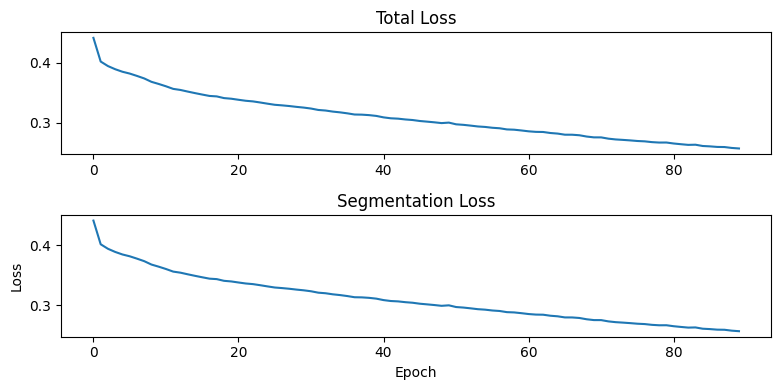

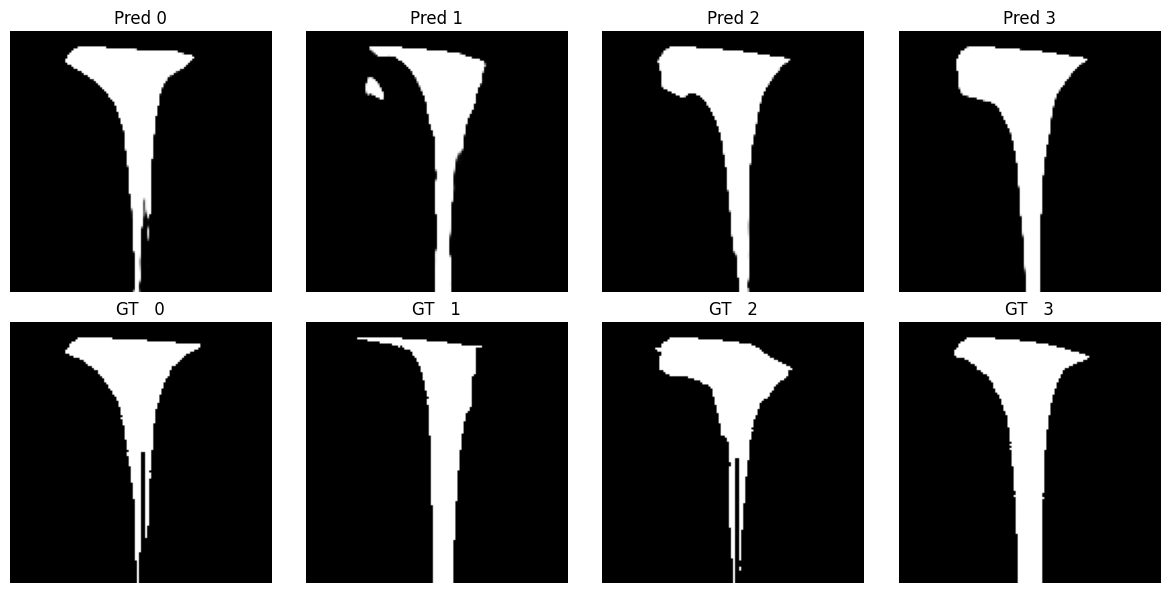

100%|██████████| 1651/1651 [02:56<00:00,  9.36it/s]


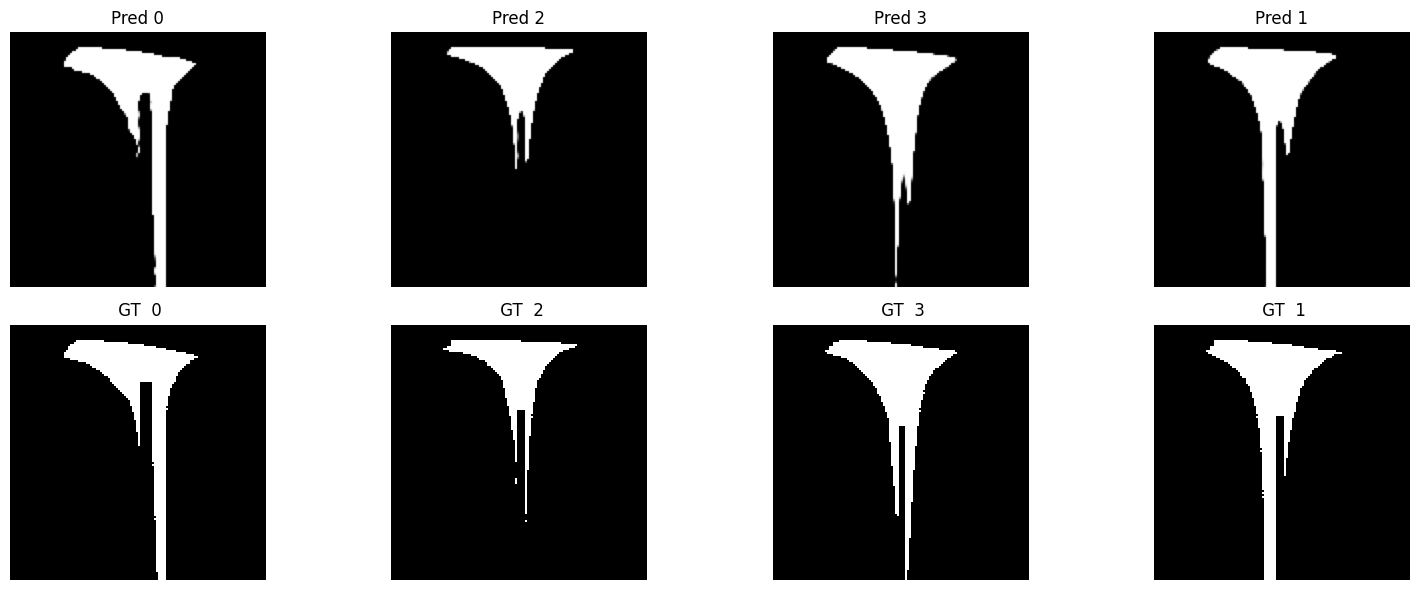

Epoch 89 val results {'pixel_acc': np.float32(0.9589585), 'iou': np.float32(0.69346917), 'dice': np.float32(0.8109431), 'precision': np.float32(0.8398958), 'recall': np.float32(0.80798644)}


100%|██████████| 1650/1650 [13:20<00:00,  2.06it/s]


Segmentation 091, Loss: 0.2556


100%|██████████| 1650/1650 [05:39<00:00,  4.86it/s]


Segmentation 092, Loss: 0.2559


...

Segmentation 093, Loss: 0.2543


100%|██████████| 1650/1650 [06:19<00:00,  4.35it/s]


Segmentation 094, Loss: 0.2548


100%|██████████| 1650/1650 [06:38<00:00,  4.15it/s]


Segmentation 095, Loss: 0.2535


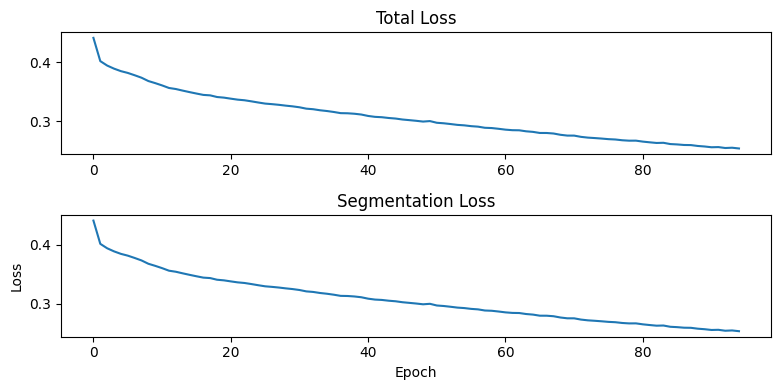

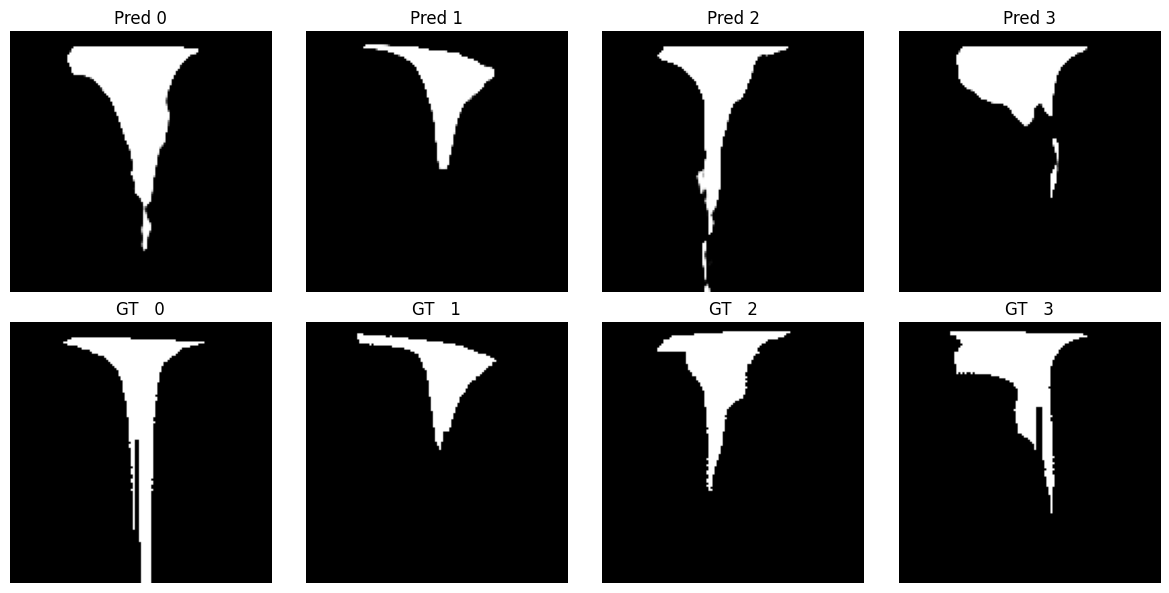

100%|██████████| 1651/1651 [02:52<00:00,  9.55it/s]


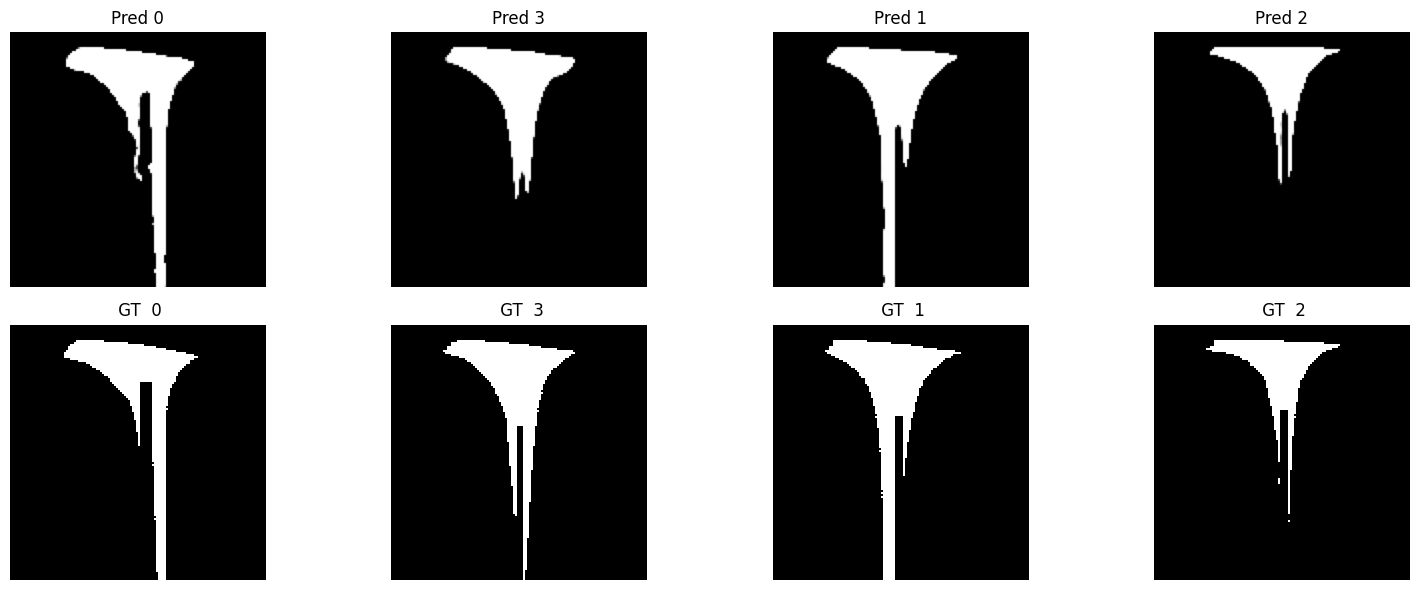

Epoch 94 val results {'pixel_acc': np.float32(0.9578549), 'iou': np.float32(0.6951041), 'dice': np.float32(0.8121034), 'precision': np.float32(0.8173701), 'recall': np.float32(0.8322655)}


100%|██████████| 1650/1650 [12:25<00:00,  2.21it/s]


Segmentation 096, Loss: 0.2519


100%|██████████| 1650/1650 [05:40<00:00,  4.85it/s]


Segmentation 097, Loss: 0.2524


...

Segmentation 098, Loss: 0.2516


100%|██████████| 1650/1650 [06:39<00:00,  4.13it/s]


Segmentation 099, Loss: 0.2510


100%|██████████| 1650/1650 [06:39<00:00,  4.13it/s]


Segmentation 100, Loss: 0.2494


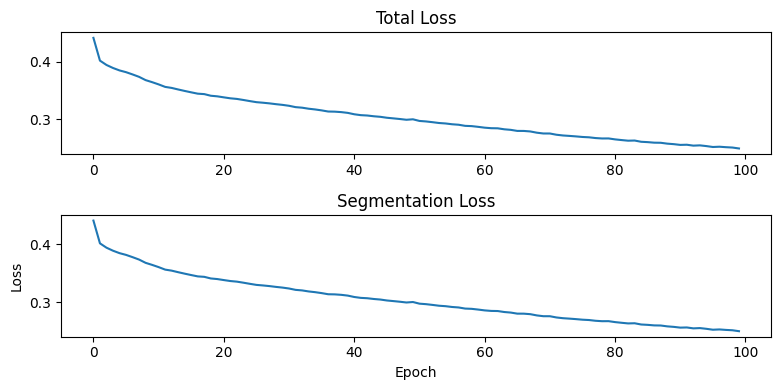

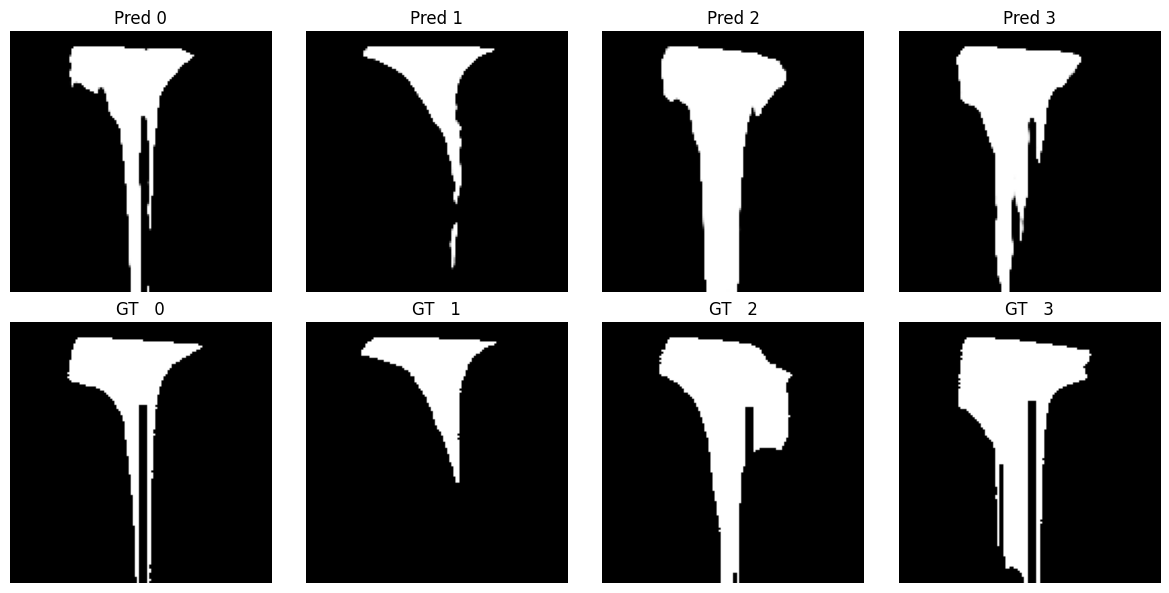

100%|██████████| 1651/1651 [02:52<00:00,  9.57it/s]


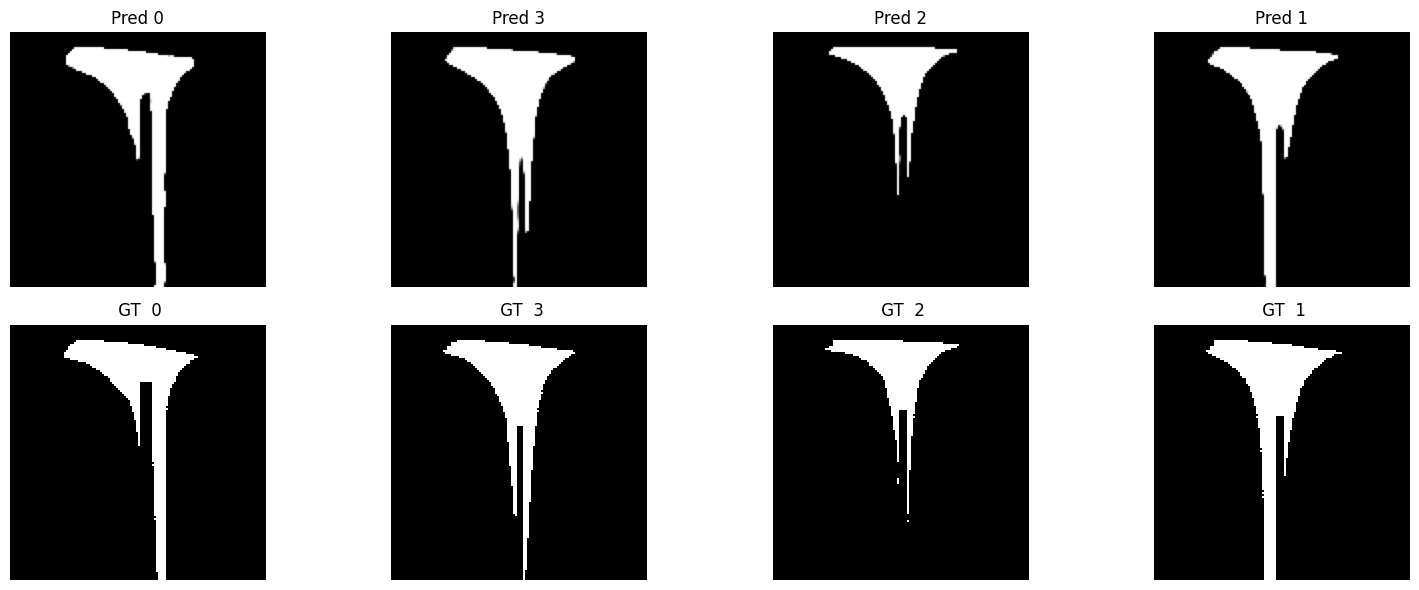

Epoch 99 val results {'pixel_acc': np.float32(0.956645), 'iou': np.float32(0.6880543), 'dice': np.float32(0.80704343), 'precision': np.float32(0.81451553), 'recall': np.float32(0.82600003)}


100%|██████████| 1650/1650 [12:36<00:00,  2.18it/s]


Segmentation 101, Loss: 0.2489


100%|██████████| 1650/1650 [05:48<00:00,  4.74it/s]


Segmentation 102, Loss: 0.2493


...

Segmentation 103, Loss: 0.2479


100%|██████████| 1650/1650 [07:18<00:00,  3.76it/s]


Segmentation 104, Loss: 0.2468


100%|██████████| 1650/1650 [06:43<00:00,  4.09it/s]


Segmentation 105, Loss: 0.2477


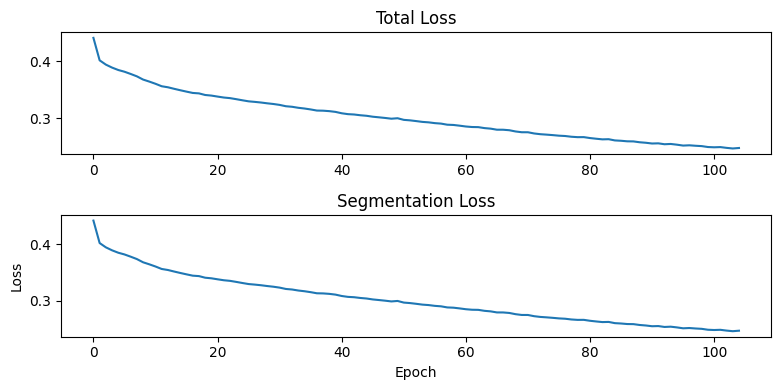

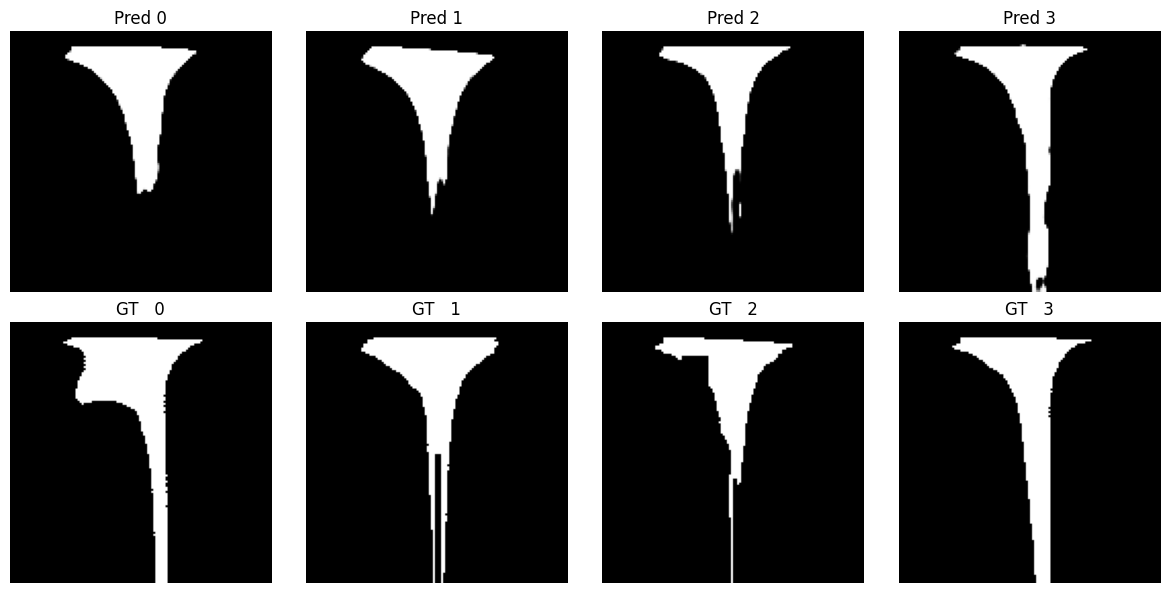

100%|██████████| 1651/1651 [02:53<00:00,  9.49it/s]


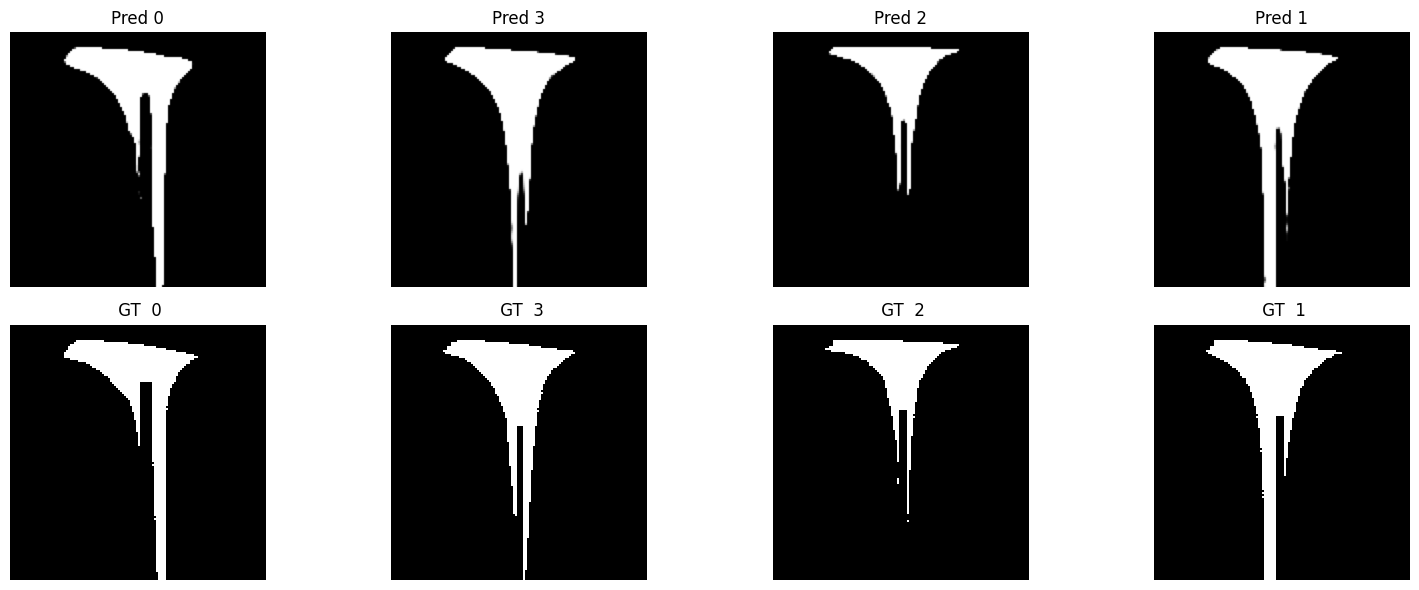

Epoch 104 val results {'pixel_acc': np.float32(0.9584714), 'iou': np.float32(0.6963816), 'dice': np.float32(0.8128659), 'precision': np.float32(0.8238251), 'recall': np.float32(0.8276518)}


100%|██████████| 1650/1650 [11:43<00:00,  2.35it/s]


Segmentation 106, Loss: 0.2462


100%|██████████| 1650/1650 [05:38<00:00,  4.88it/s]


Segmentation 107, Loss: 0.2449


...

Segmentation 108, Loss: 0.2446


100%|██████████| 1650/1650 [05:52<00:00,  4.68it/s]


Segmentation 109, Loss: 0.2443


100%|██████████| 1650/1650 [05:55<00:00,  4.65it/s]


Segmentation 110, Loss: 0.2433


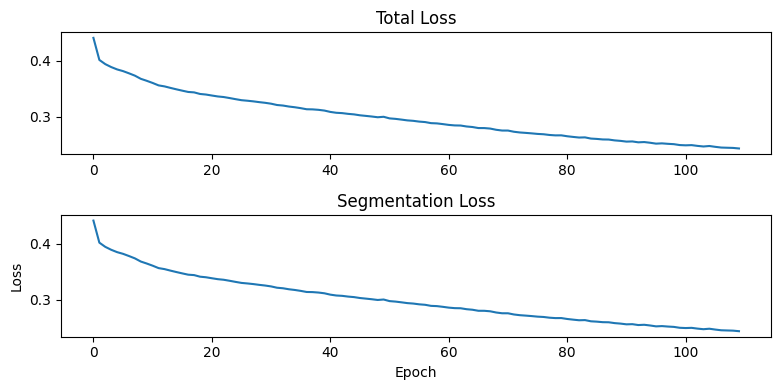

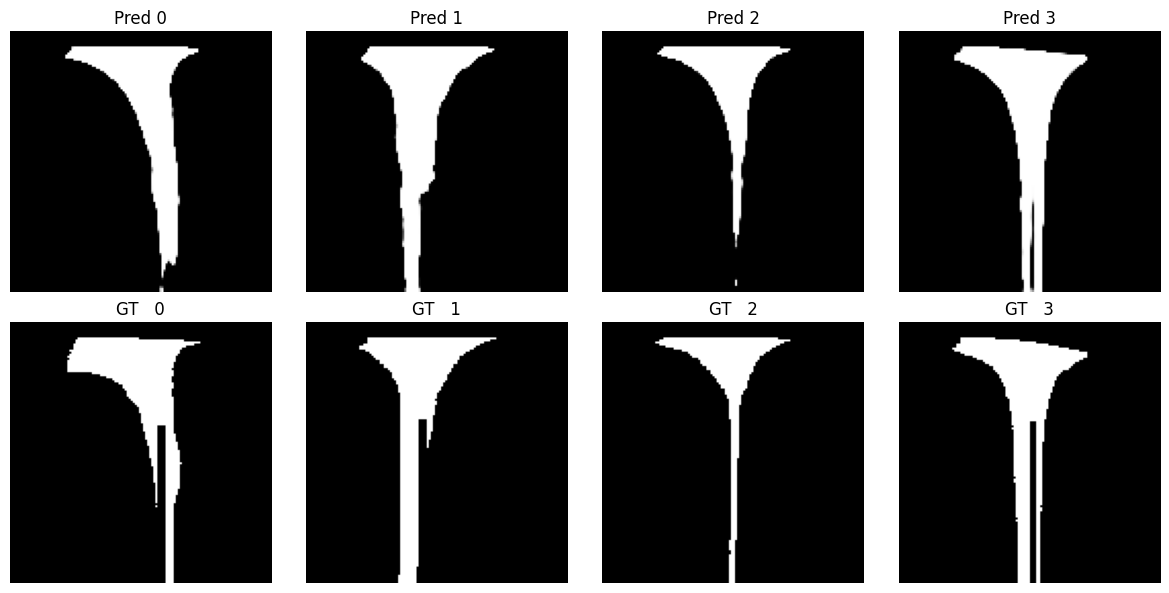

100%|██████████| 1651/1651 [02:55<00:00,  9.42it/s]


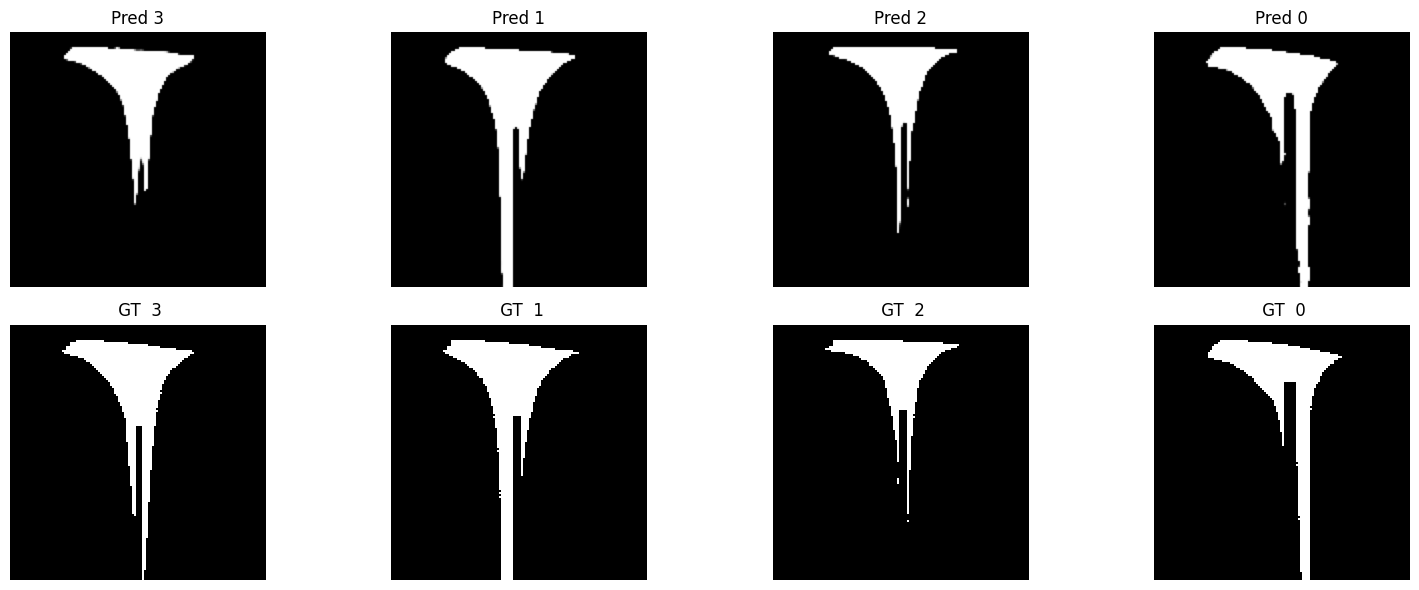

Epoch 109 val results {'pixel_acc': np.float32(0.956885), 'iou': np.float32(0.69202024), 'dice': np.float32(0.8094866), 'precision': np.float32(0.80509174), 'recall': np.float32(0.84013504)}


100%|██████████| 1650/1650 [13:27<00:00,  2.04it/s]


Segmentation 111, Loss: 0.2432


100%|██████████| 1650/1650 [05:47<00:00,  4.75it/s]


Segmentation 112, Loss: 0.2429


...

Segmentation 113, Loss: 0.2426


100%|██████████| 1650/1650 [06:48<00:00,  4.04it/s]


Segmentation 114, Loss: 0.2406


100%|██████████| 1650/1650 [06:50<00:00,  4.02it/s]


Segmentation 115, Loss: 0.2410


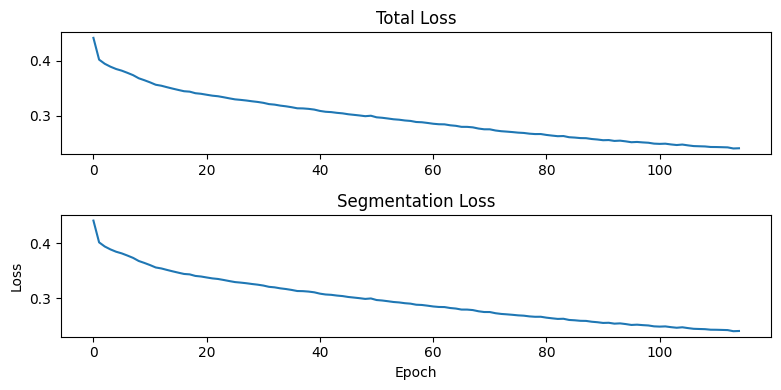

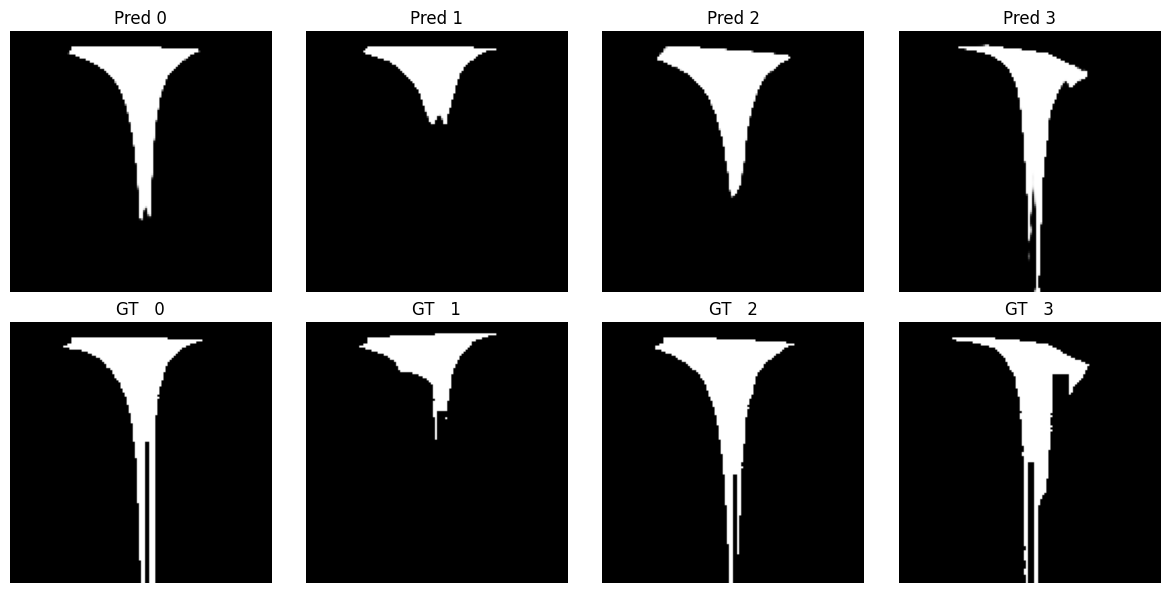

100%|██████████| 1651/1651 [02:53<00:00,  9.53it/s]


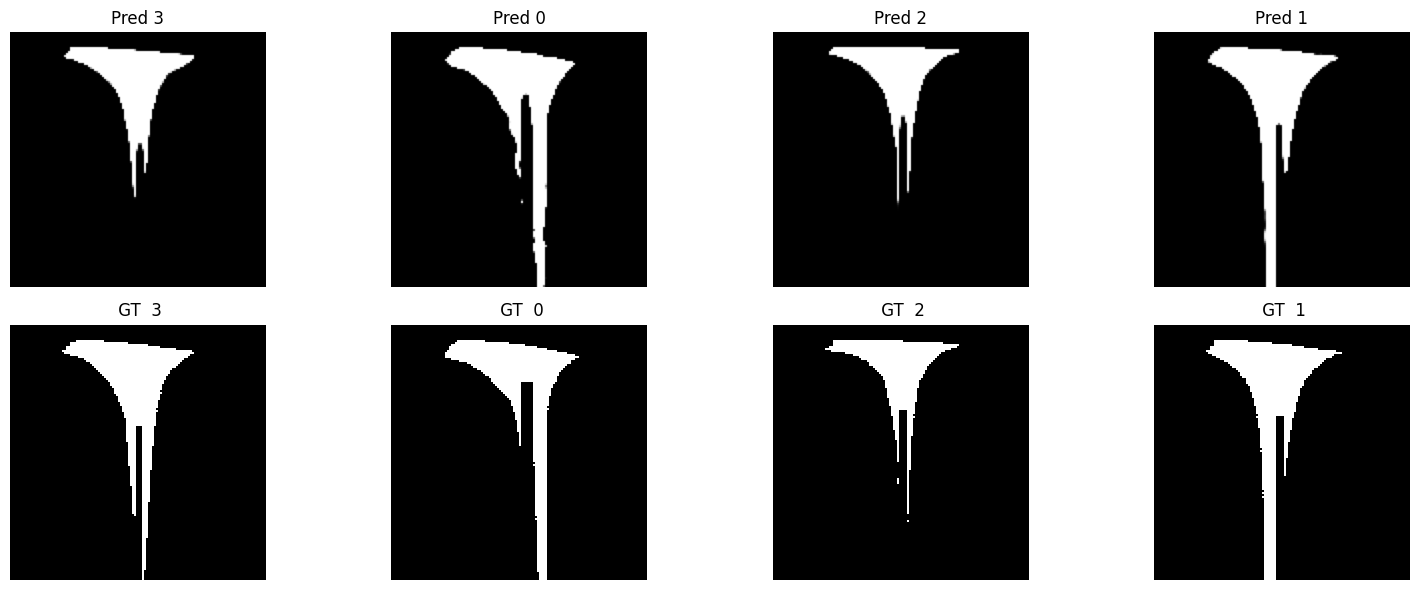

Epoch 114 val results {'pixel_acc': np.float32(0.95956033), 'iou': np.float32(0.6979295), 'dice': np.float32(0.8138815), 'precision': np.float32(0.8442626), 'recall': np.float32(0.8094138)}


100%|██████████| 1650/1650 [12:36<00:00,  2.18it/s]


Segmentation 116, Loss: 0.2406


100%|██████████| 1650/1650 [05:40<00:00,  4.84it/s]


Segmentation 117, Loss: 0.2401


...

Segmentation 118, Loss: 0.2395


100%|██████████| 1650/1650 [06:07<00:00,  4.49it/s]


Segmentation 119, Loss: 0.2391


100%|██████████| 1650/1650 [06:02<00:00,  4.55it/s]


Segmentation 120, Loss: 0.2391


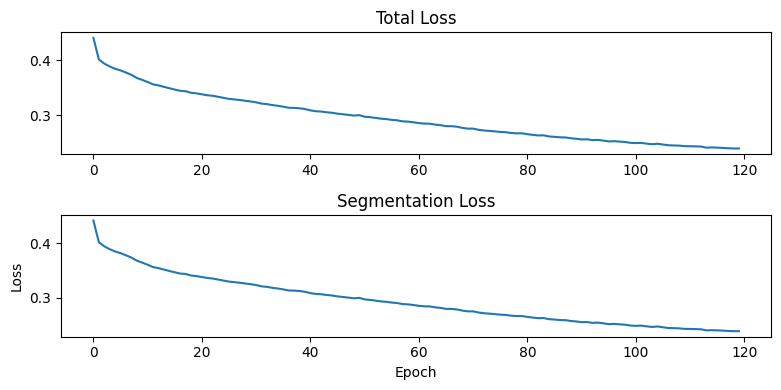

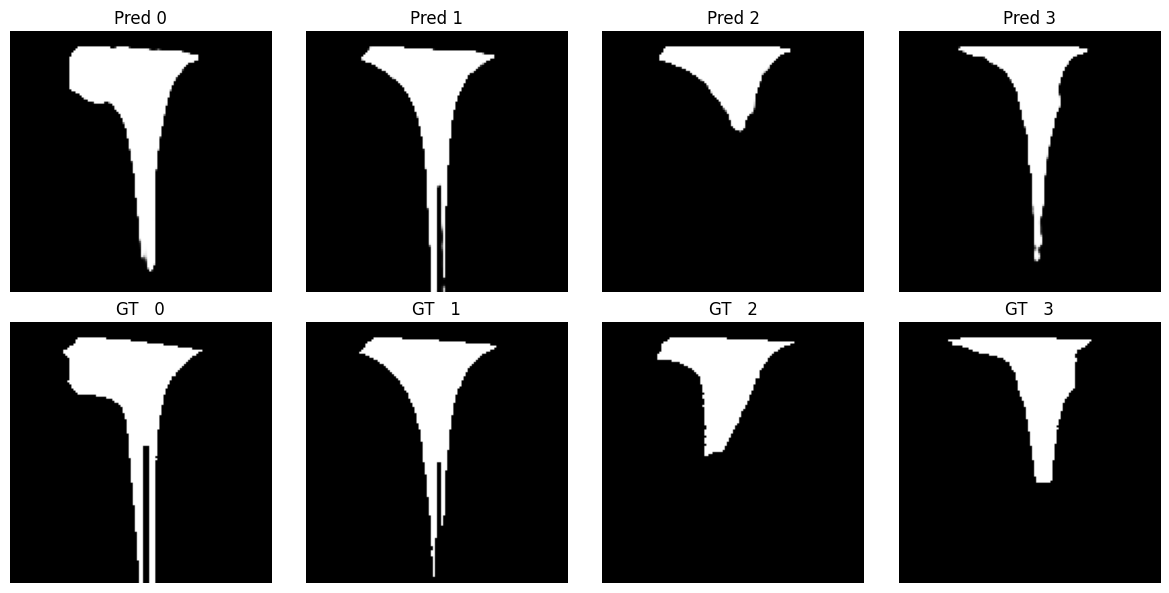

100%|██████████| 1651/1651 [02:54<00:00,  9.45it/s]


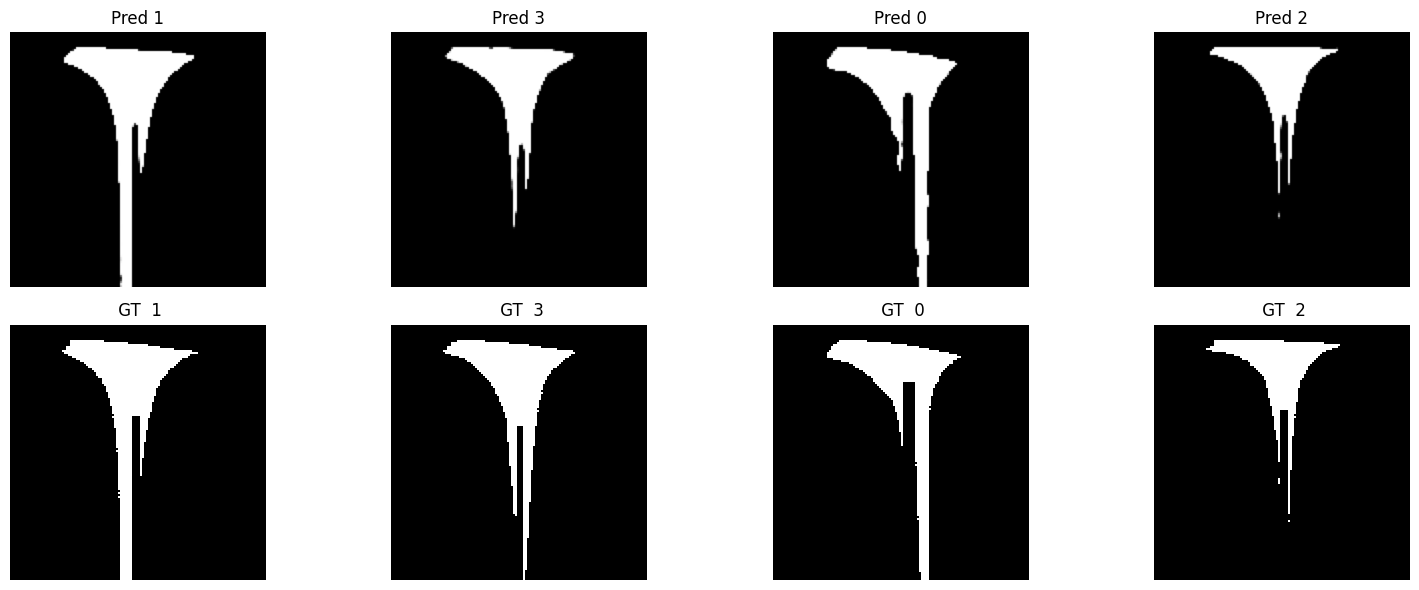

Epoch 119 val results {'pixel_acc': np.float32(0.95907664), 'iou': np.float32(0.69554937), 'dice': np.float32(0.81232965), 'precision': np.float32(0.8400088), 'recall': np.float32(0.81100494)}


100%|██████████| 1650/1650 [13:02<00:00,  2.11it/s]


Segmentation 121, Loss: 0.2382


100%|██████████| 1650/1650 [05:39<00:00,  4.87it/s]


Segmentation 122, Loss: 0.2368


...

Segmentation 123, Loss: 0.2375


100%|██████████| 1650/1650 [05:47<00:00,  4.75it/s]


Segmentation 124, Loss: 0.2363


100%|██████████| 1650/1650 [05:48<00:00,  4.74it/s]


Segmentation 125, Loss: 0.2364


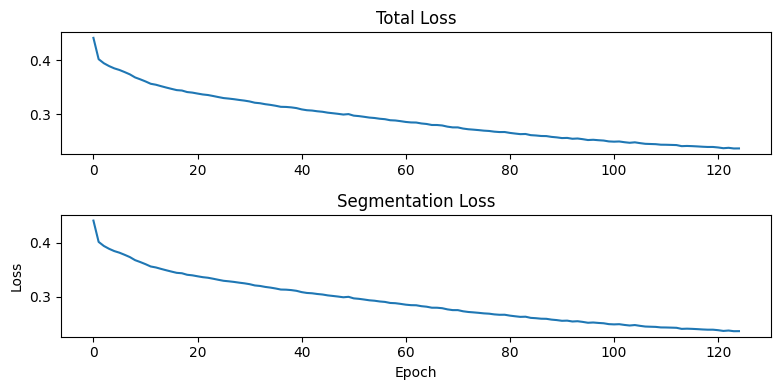

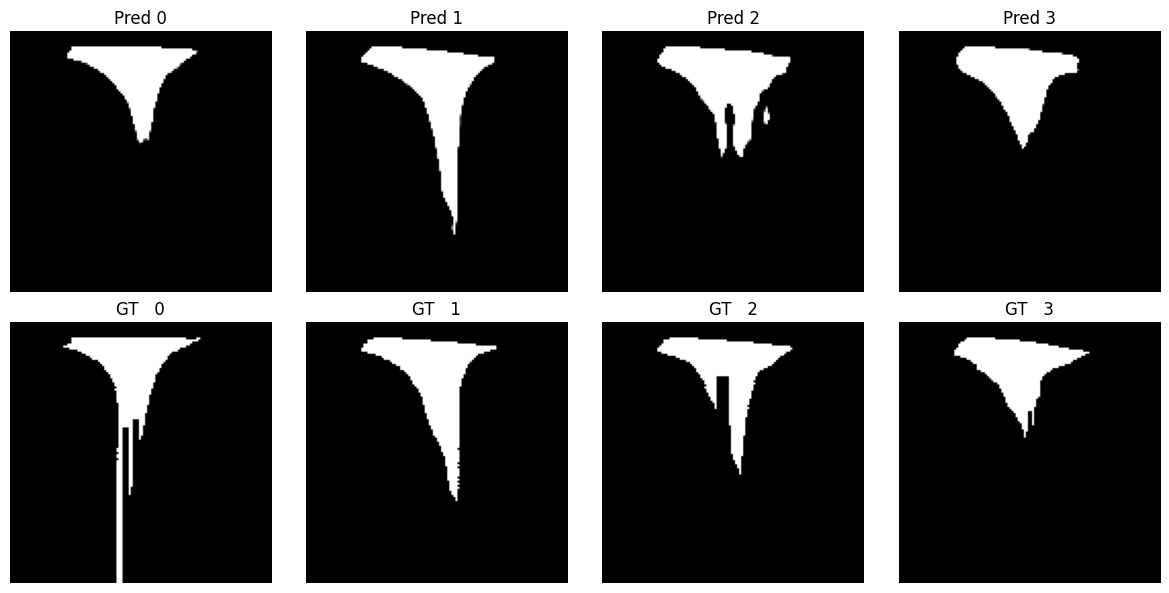

100%|██████████| 1651/1651 [02:53<00:00,  9.54it/s]


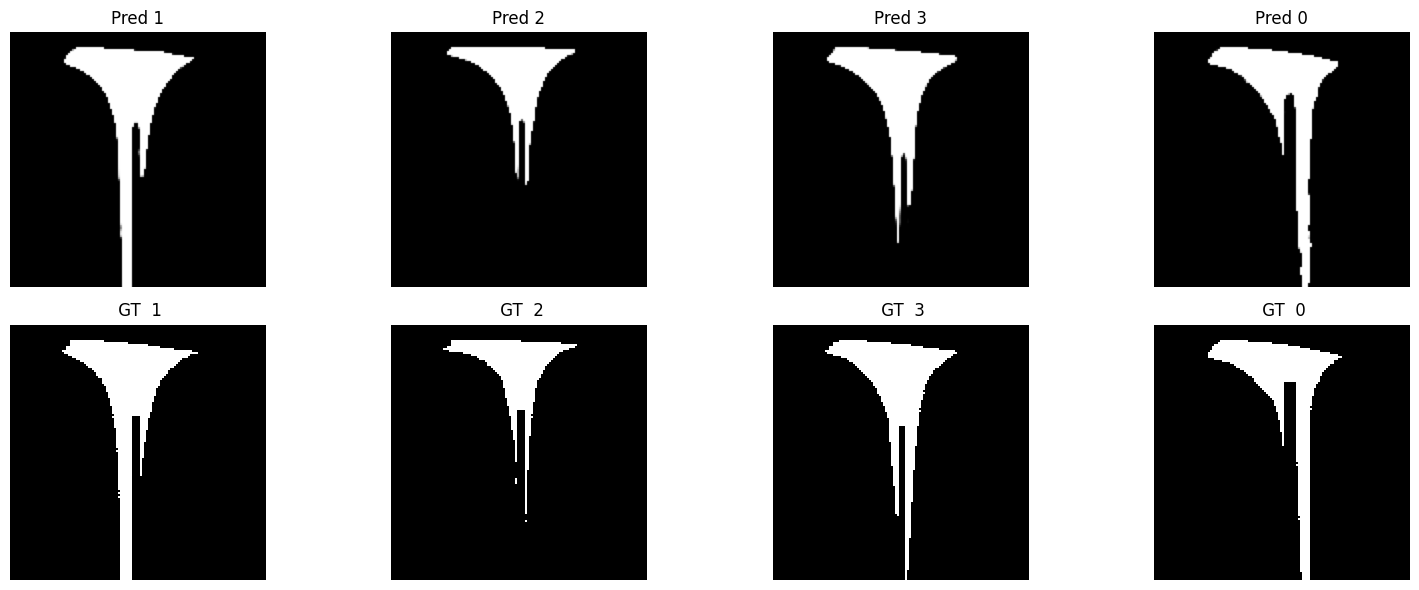

Epoch 124 val results {'pixel_acc': np.float32(0.9580393), 'iou': np.float32(0.69556344), 'dice': np.float32(0.8121858), 'precision': np.float32(0.81389195), 'recall': np.float32(0.8364065)}


 42%|████▏     | 687/1650 [05:27<05:43,  2.80it/s]

In [ ]:

# Loss list
epoch_losses       = []
seg_losses         = []
rec_losses         = []    # reconstruction / prediction
mutual_losses      = []
contrastive_losses = []

# seg_loss = JaccardLoss()

for epoch in range(num_epochs):
# for epoch in range(6):
    epoch_loss = 0.0
    rec_acc, mutual_acc, excl_acc, inter_acc, seg_acc = 0., 0., 0., 0., 0.
    batch_no = 0

    last_pred_masks = None
    last_gt_masks   = None

    encoder_radar.train()
    # decoder_radar.train()

    # --- Example usage ---
    # for batch in tqdm(dataloader, desc=f"Epoch {epoch}"):

    for batch in tqdm(train_dataloader):
        batch_no += 1

        ## Data batch
        radar_batch = batch["radar"].to(device)       # [B, C', H, W]
        mask_batch = batch["mask"].to(device)


        ## Generate Embeddings
        mask_logits = encoder_radar(radar_batch)    # radar embedding

        # decode segmentation mask
        #  = decoder_radar(radar_encoding)

        segmentation_loss = JaccardLoss(mask_logits, mask_batch)

        # — loss & unpack sub-terms —



        total_loss = segmentation_loss

        # Storing losses

        epoch_loss  += total_loss.item()
        seg_acc     += segmentation_loss.item()

        # batch update
        optim_enc_rad.zero_grad()
        # optim_dec_rad.zero_grad()
        total_loss.backward()
        optim_enc_rad.step()
        # optim_dec_rad.step()
        # if batch_no == 200:
        #     break


    with torch.no_grad():
        last_pred_masks = torch.sigmoid(mask_logits).cpu()
        last_gt_masks   = mask_batch.cpu()

    # compute per-epoch averages
    N = batch_no
    epoch_losses.append(epoch_loss / N)
    rec_losses.append(rec_acc / N)
    mutual_losses.append(mutual_acc / N)
    contrastive_losses.append((excl_acc) / N)
    seg_losses.append(seg_acc/N)
    # print(f"Epoch {epoch+1:03d}, Loss: {epoch_loss/N:.4f}")
    print(f"Segmentation {epoch+1:03d}, Loss: {seg_acc/N:.4f}")

    # === checkpoint every some epochs ===
    if (epoch + 1) % checkpoint_frequency == 0:
        ckpt_path = os.path.join(ckpt_dir, f"epoch_{epoch+1:03d}.pth")
        torch.save({
            'epoch': epoch + 1,
            'encoder_radar': encoder_radar.state_dict(),
            'optim_enc_rad': optim_enc_rad.state_dict(),
            # 'optim_dec_rad': optim_dec_rad.state_dict(),
            'loss': epoch_loss / batch_no,
        }, ckpt_path)
        # print(f"  → Saved checkpoint: {ckpt_path}")


    ## Plotting every some epochs
    if (epoch+1) % plot_frequency == 0:

        # —— 1) loss curves —— 
        plt.figure(num="Training Losses", figsize=(8,4))
        plt.subplot(211), plt.plot(epoch_losses),       plt.title("Total Loss")
        plt.subplot(212), plt.plot(seg_losses),       plt.title("Segmentation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.tight_layout()
        plt.show()

        if last_pred_masks is not None:
            fig, axes = plt.subplots(2, 4, figsize=(12, 6), num="Training samples")
            for i in range(4):
                # Predicted mask
                axes[0, i].imshow(last_pred_masks[i, 0], cmap='gray')
                axes[0, i].set_title(f'Pred {i}')
                axes[0, i].axis('off')
                # Ground-truth mask
                axes[1, i].imshow(last_gt_masks[i, 0], cmap='gray')
                axes[1, i].set_title(f'GT   {i}')
                axes[1, i].axis('off')
            plt.tight_layout()
            plt.show()

    ## Do validation
    if (epoch+1) % validation_frequency == 0:
        # print("Running evaluation")
        val_output = validate(encoder_radar, val_dataloader, device)
        print(f"Epoch {epoch} val results {val_output}")


